<a href="https://colab.research.google.com/github/saitejakchintaginjal/AIML-Projects/blob/main/Easyvisa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    RandomForestClassifier,
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import make_scorer, recall_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate
)

import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data = pd.read_csv('/content/drive/MyDrive/EasyVisa.csv')

In [ ]:
df = data.copy()

# Data Overview

In [ ]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [ ]:
df.tail()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.57,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.79,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.85,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.77,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.91,Year,Y,Certified


In [ ]:
df.shape

(25480, 12)

Observation : The dataset contains 25,480 observations and 12 variables.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


Observation: The dataset contains both numerical and categorical variables.

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_employees,25480.0,5667.043210,22877.928848,-26.0000,1022.00,2109.00,3504.0000,602069.00
yr_of_estab,25480.0,1979.409929,42.366929,1800.0000,1976.00,1997.00,2005.0000,2016.00
prevailing_wage,25480.0,74455.814592,52815.942327,2.1367,34015.48,70308.21,107735.5125,319210.27


In [ ]:
df.describe(include="object").T

,count,unique,top,freq
case_id,25480,25480,EZYV25480,1
continent,25480,6,Asia,16861
education_of_employee,25480,4,Bachelor's,10234
has_job_experience,25480,2,Y,14802
requires_job_training,25480,2,N,22525
region_of_employment,25480,5,Northeast,7195
unit_of_wage,25480,4,Year,22962
full_time_position,25480,2,Y,22773
case_status,25480,2,Certified,17018


Observation :

* no_of_employees has a negative value (-26) and extreme values, indicating possible data errors/outliers.
* yr_of_estab ranges from 1800 to 2016, with most companies established in recent years.
* prevailing_wage has high variation and possible outliers.
* case_id is unique for every record and can be dropped for modeling.
* Most applicants are from Asia and have a Bachelor's degree.
* Most applicants have job experience and do not require job training.
* Most jobs are full-time and wages are mainly measured yearly.
* case_status is imbalanced, with Certified as the majority class.

In [ ]:
for col in df.select_dtypes(include="object").columns:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())


Column: case_id
case_id
EZYV25480    1
EZYV01       1
EZYV02       1
EZYV03       1
EZYV04       1
            ..
EZYV13       1
EZYV12       1
EZYV11       1
EZYV10       1
EZYV09       1
Name: count, Length: 25480, dtype: int64

Column: continent
continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64

Column: education_of_employee
education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64

Column: has_job_experience
has_job_experience
Y    14802
N    10678
Name: count, dtype: int64

Column: requires_job_training
requires_job_training
N    22525
Y     2955
Name: count, dtype: int64

Column: region_of_employment
region_of_employment
Northeast    7195
South        7017
West         6586
Midwest      4307
Island        375
Name: count, dtype: int64

Column: unit_of_wage
unit_of_wage
Year     22962


Dataset Observation

The dataset consists of 25,480 visa applications and 12 variables. The variables contain both employee-related and employer-related information. case_status is the target variable, while case_id is a unique application identifier

# EDA

In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

categorical_cols = df.select_dtypes(include="object").columns.tolist()

print("Numerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
['no_of_employees', 'yr_of_estab', 'prevailing_wage']

Categorical Columns:
['case_id', 'continent', 'education_of_employee', 'has_job_experience', 'requires_job_training', 'region_of_employment', 'unit_of_wage', 'full_time_position', 'case_status']


Univariate Analysis

In [ ]:
# Numerical variables
def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins="auto"):
    fig, (ax_box, ax_hist) = plt.subplots(
        nrows=2,
        sharex=True,
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize
    )

    sns.boxplot(
        data=df,
        x=feature,
        ax=ax_box,
        showmeans=True
    )

    sns.histplot(
        data=df,
        x=feature,
        kde=kde,
        bins=bins,
        ax=ax_hist
    )

    plt.show()

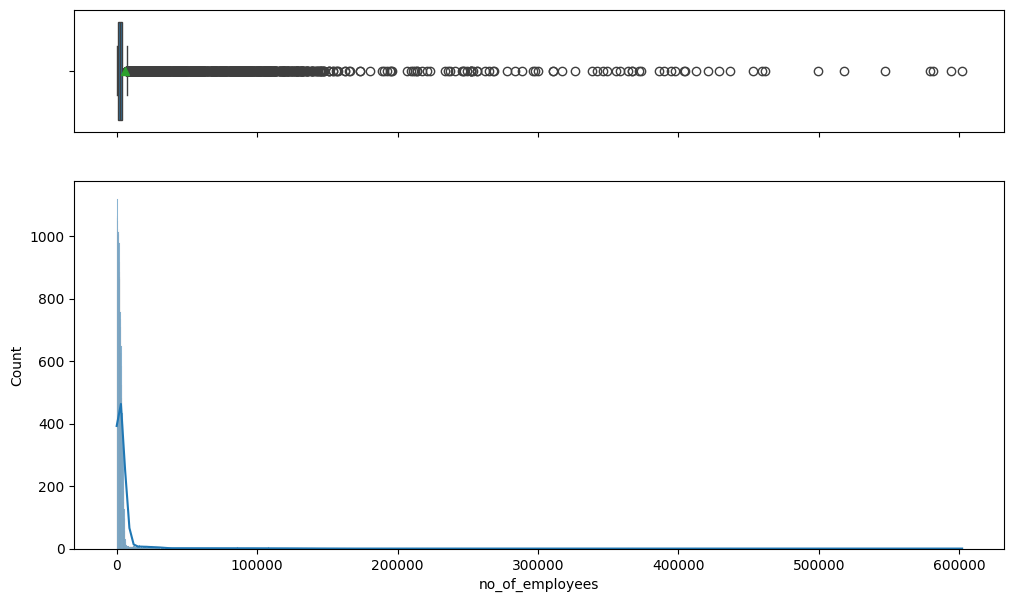

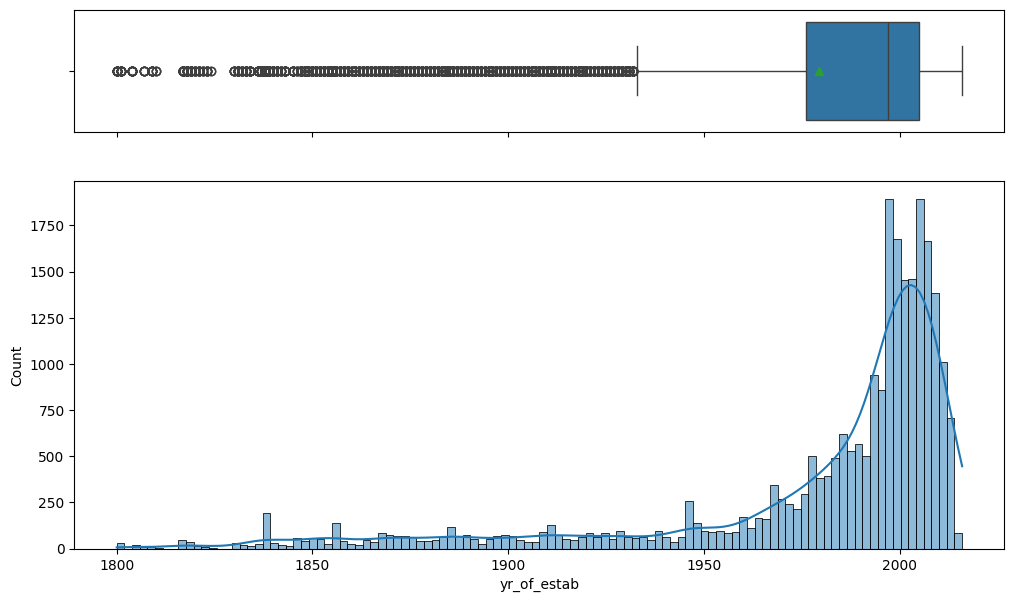

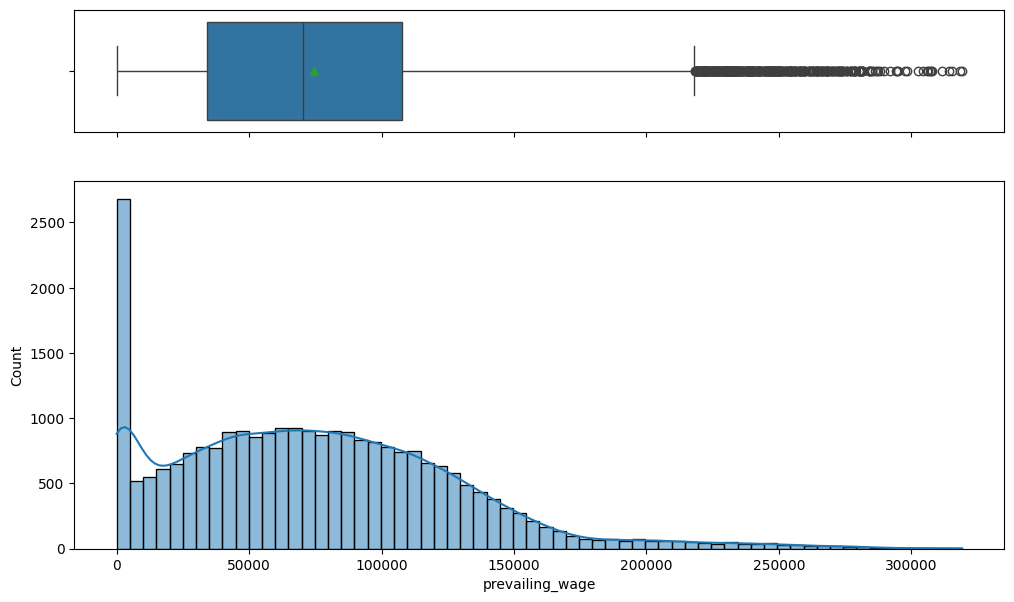

In [ ]:
for column in numerical_cols:
    histogram_boxplot(df, column, kde=True)

Observations :
* no_of_employees: Highly right-skewed with a large number of outliers. Most companies have a relatively low employee count.
* prevailing_wage: Right-skewed with several high-value outliers. Most wages are concentrated around 40,000-120,000.
* yr_of_estab: Left-skewed with several older-year outliers. Most companies were established between 1980 and 2010.

Bivariate Analysis

In [ ]:
# case_id is an identifier and should not be treated as a meaningful categorical feature.
categorical_cols.remove("case_id")

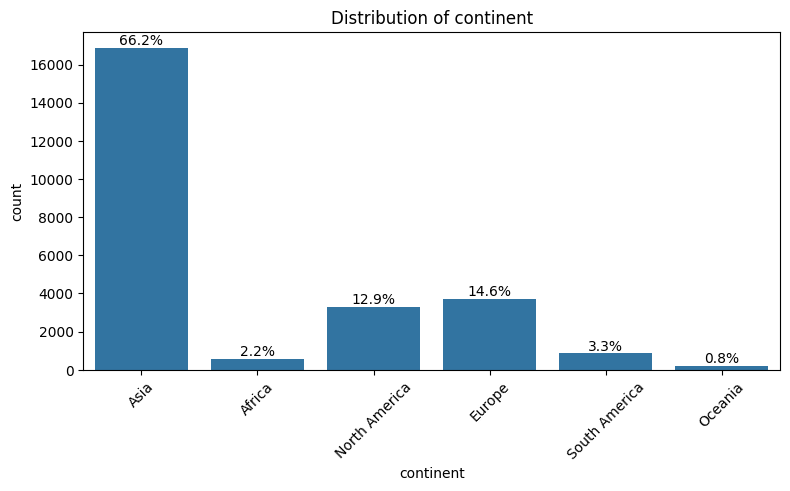

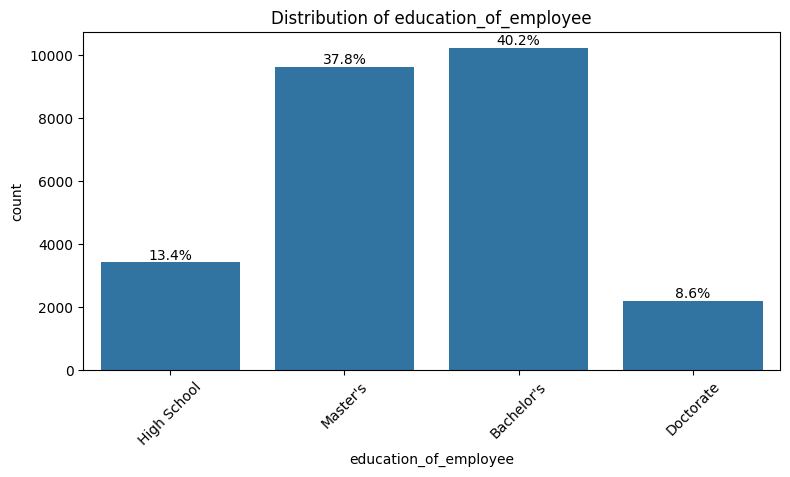

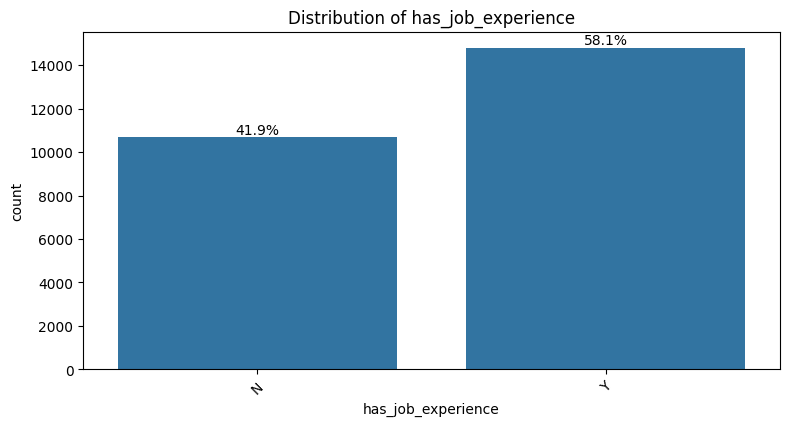

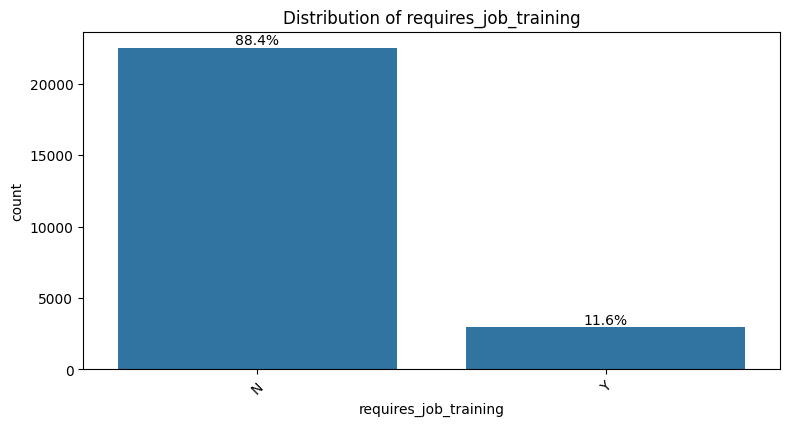

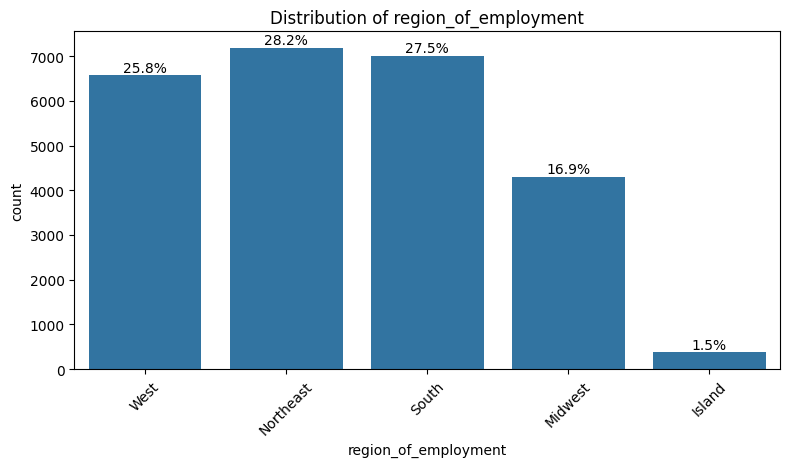

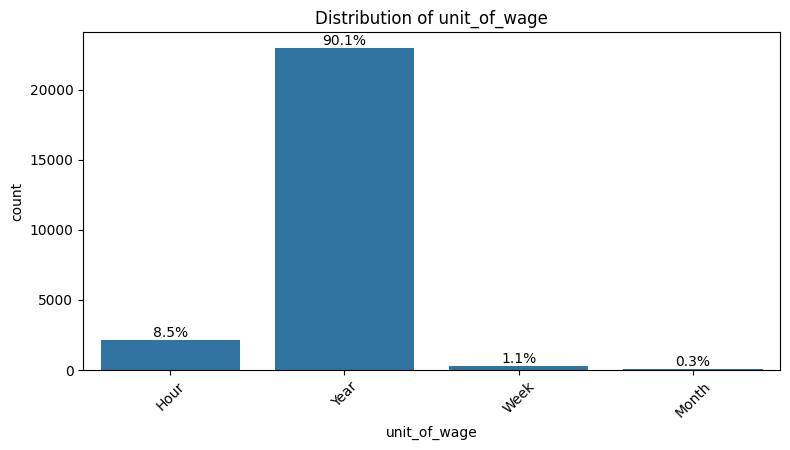

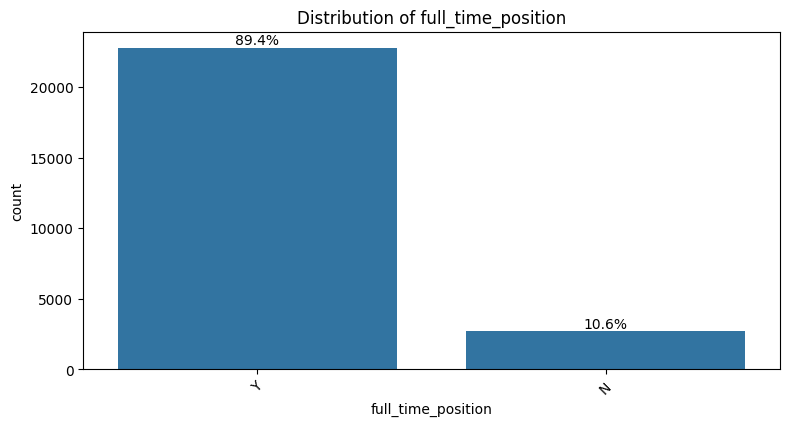

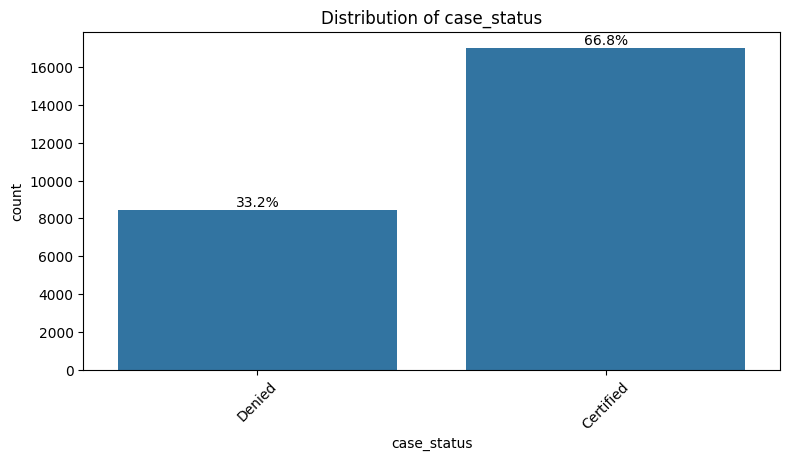

In [ ]:
# Categorical Variables

for column in categorical_cols:
    plt.figure(figsize=(8, 5))

    ax = sns.countplot(
        data=df,
        x=column
    )

    total = len(df)

    for container in ax.containers:
        labels = [
            f"{(value / total) * 100:.1f}%"
            for value in container.datavalues
        ]
        ax.bar_label(container, labels=labels)

    plt.xticks(rotation=45)
    plt.title(f"Distribution of {column}")
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.25)
    plt.show()

    print("\n")

Observations :

* Continent: Majority of applicants are from Asia.
* Education: Most applicants have Bachelor's or Master's degrees.
* Job Experience: More applicants have job experience.
* Job Training: Most jobs do not require training.
* Region: Northeast and South have the highest number of employment cases; * Island has the least.
* Unit of Wage: Most wages are measured yearly.
* Full-Time Position: Majority of jobs are full-time.
* Case Status: Certified cases are higher than denied cases, showing class imbalance.

Target Variable Analysis



In [ ]:
df["case_status"].value_counts()

,count
case_status,
Certified,17018
Denied,8462


In [ ]:
df["case_status"].value_counts(normalize=True) * 100

,proportion
case_status,
Certified,66.789639
Denied,33.210361


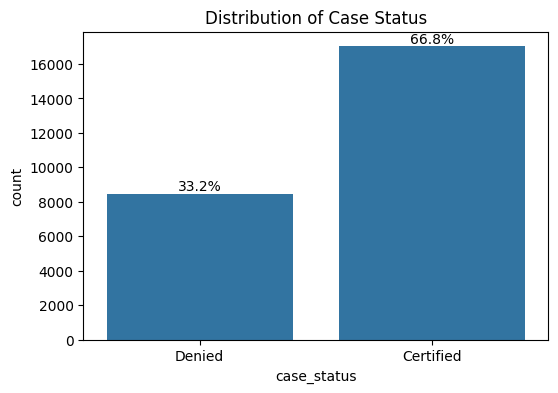

In [ ]:
plt.figure(figsize=(6, 4))

ax = sns.countplot(
    data=df,
    x="case_status"
)

total = len(df)

for container in ax.containers:
    labels = [
        f"{(value / total) * 100:.1f}%"
        for value in container.datavalues
    ]
    ax.bar_label(container, labels=labels)

plt.title("Distribution of Case Status")
plt.show()

In [ ]:
pd.crosstab(
    df["education_of_employee"],
    df["case_status"],
    normalize="index"
) * 100

case_status,Certified,Denied
education_of_employee,,
Bachelor's,62.214188,37.785812
Doctorate,87.226277,12.773723
High School,34.035088,65.964912
Master's,78.627777,21.372223


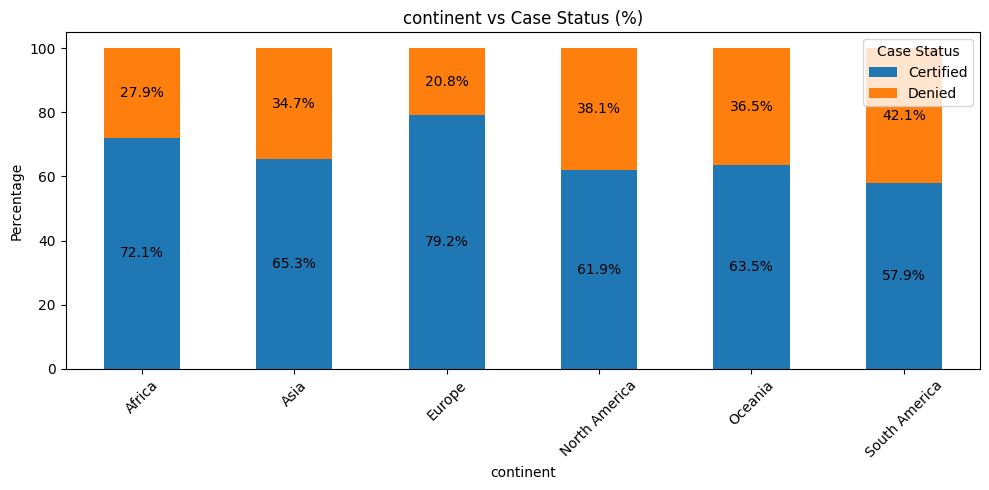

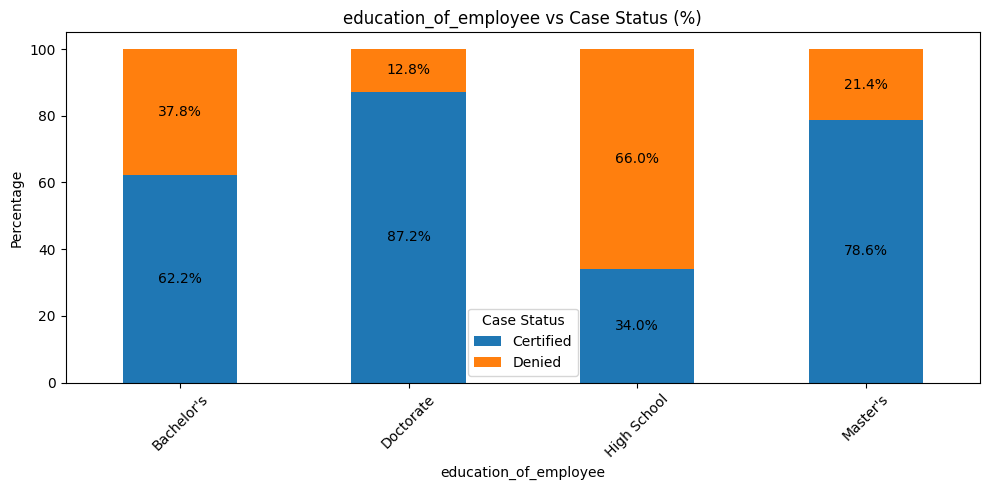

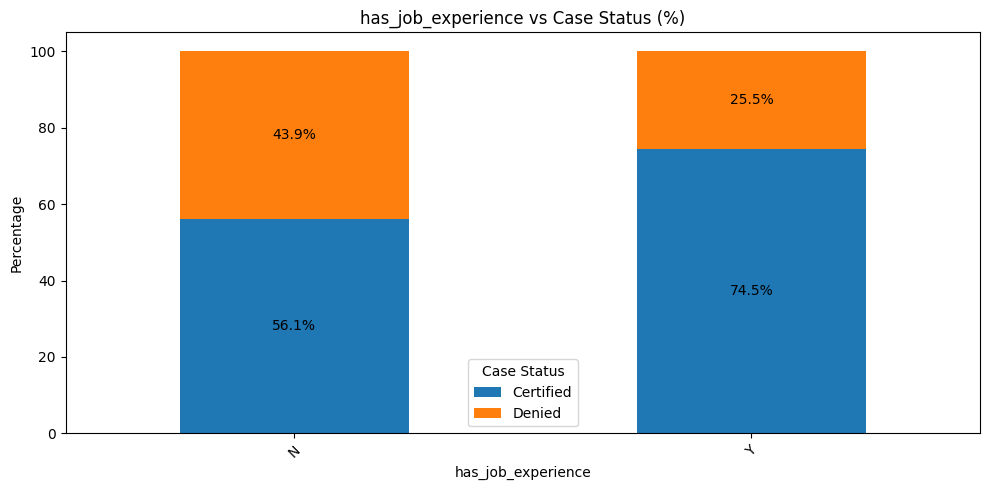

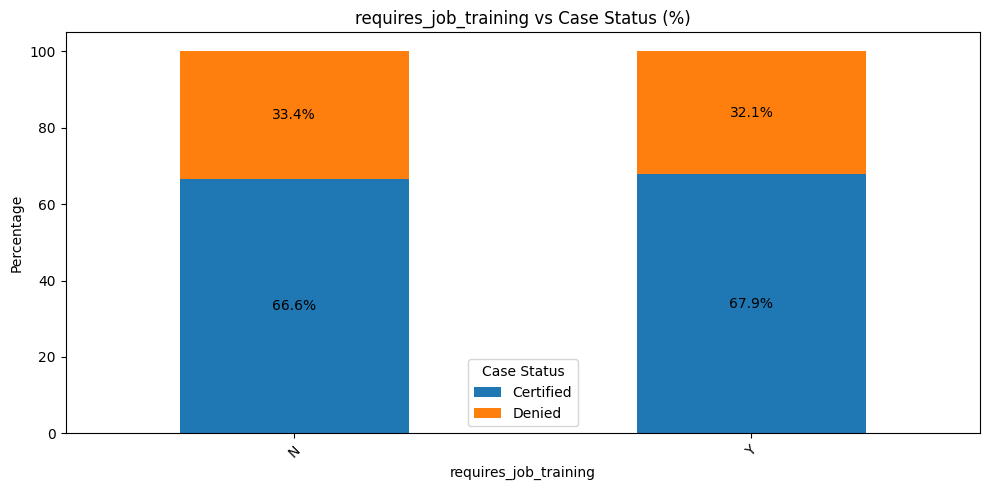

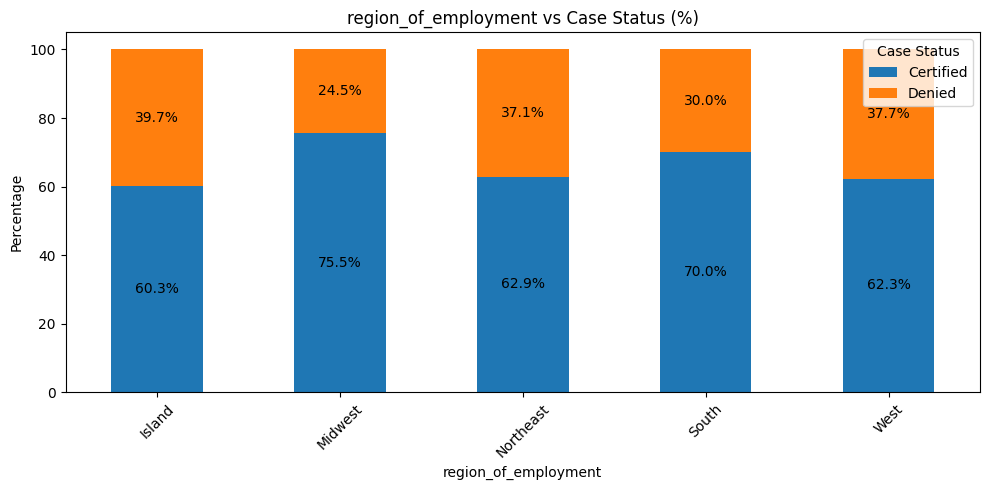

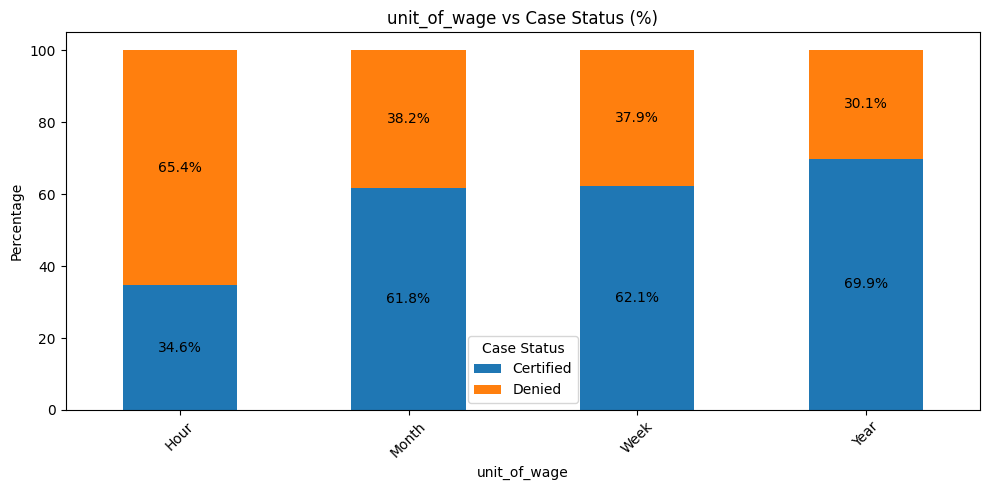

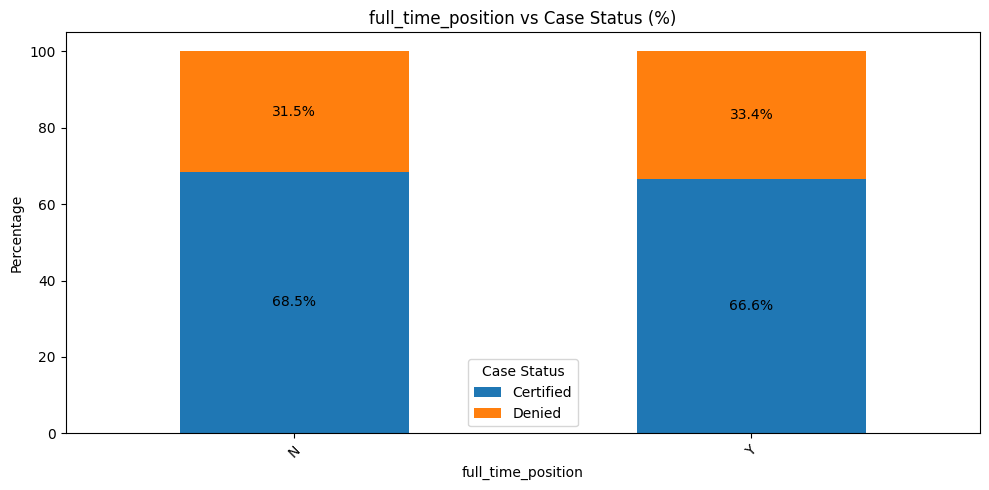

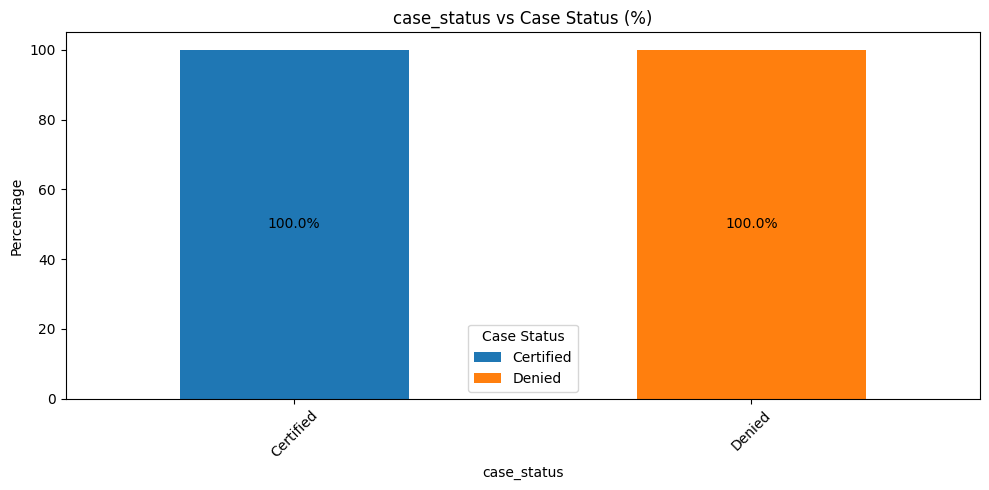

In [ ]:
# Categorical feature vs target

for column in categorical_cols:

    percentage = pd.crosstab(
        df[column],
        df["case_status"],
        normalize="index"
    ) * 100

    ax = percentage.plot(
        kind="bar",
        stacked=True,
        figsize=(10, 5)
    )

    # Add percentage labels
    for container in ax.containers:
        labels = [
            f"{value:.1f}%" if value > 0 else ""
            for value in container.datavalues
        ]

        ax.bar_label(
            container,
            labels=labels,
            label_type="center"
        )

    plt.title(f"{column} vs Case Status (%)")
    plt.ylabel("Percentage")
    plt.xticks(rotation=45)
    plt.legend(title="Case Status")
    plt.tight_layout()
    plt.show()
    print("\n")

Observations :

* Continent: Europe has the highest certification rate (79.2%), while South America has the lowest (57.9%).
* Education: Doctorate holders have the highest certification rate (87.2%), while High School applicants have the lowest (34%).
* Job Experience: Applicants with job experience have a higher certification rate (74.5%) than those without experience (56.1%).
* Job Training: Certification rates are almost similar, indicating job training has little impact.
* Region: Midwest has the highest certification rate (75.5%), followed by South (70%).
* Unit of Wage: Yearly wages have the highest certification rate (69.9%), while hourly wages have the lowest (34.6%).
* Full-Time Position: Certification rates are very similar, suggesting full-time status has little impact on case status.

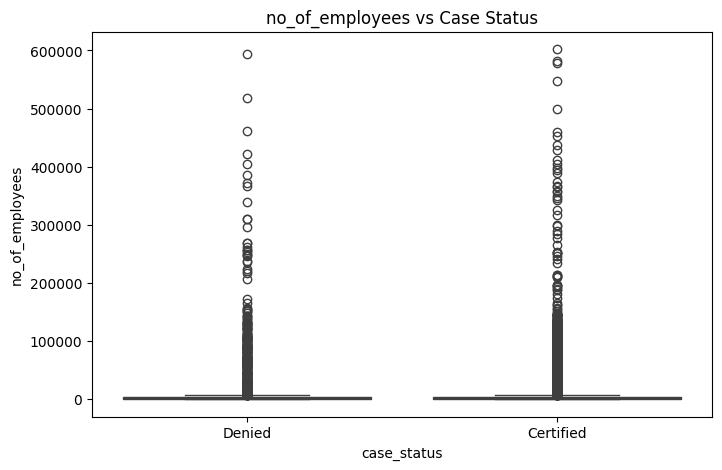

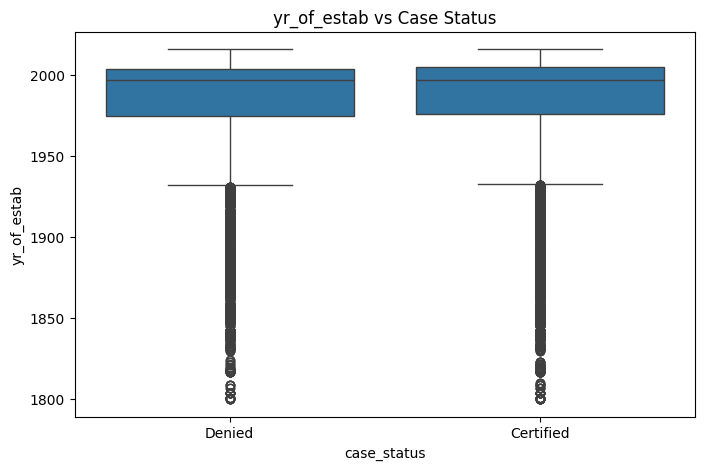

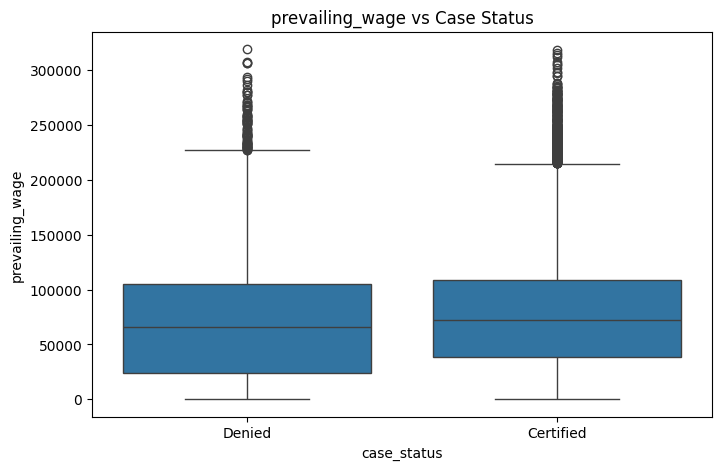

In [ ]:
# Numerical feature vs target

for col in numerical_cols:
    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=df,
        x="case_status",
        y=col
    )

    plt.title(f"{col} vs Case Status")
    plt.show()
    print("\n")

Observation :

* no_of_employees: Both case statuses show a highly right-skewed distribution with many extreme outliers, and no clear difference between Denied and Certified cases.
* yr_of_estab: Certified cases have a slightly higher median establishment year, but the distributions largely overlap, indicating a weak relationship with case status.
* prevailing_wage: Certified cases show a slightly higher median prevailing wage than Denied cases, although substantial overlap exists between the two groups.

Multivariate Analysis

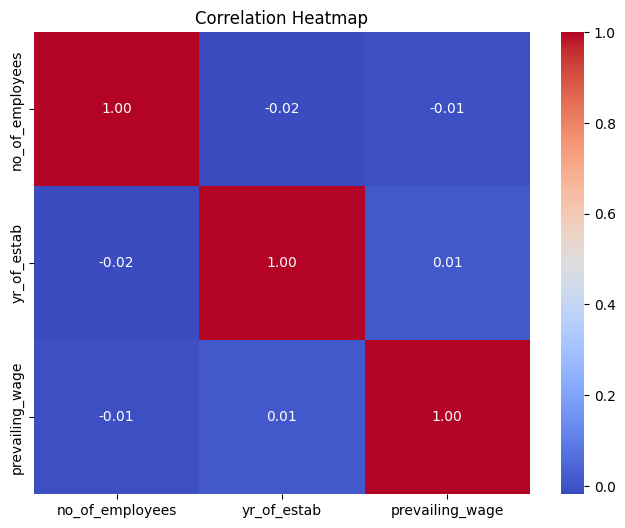

In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    df[numerical_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

Observations :

* The numerical variables show very weak or almost no correlation with each other.
* Correlation values are close to 0 (-0.02 to 0.01).
* Hence, there is no significant linear relationship or multicollinearity among the numerical features.

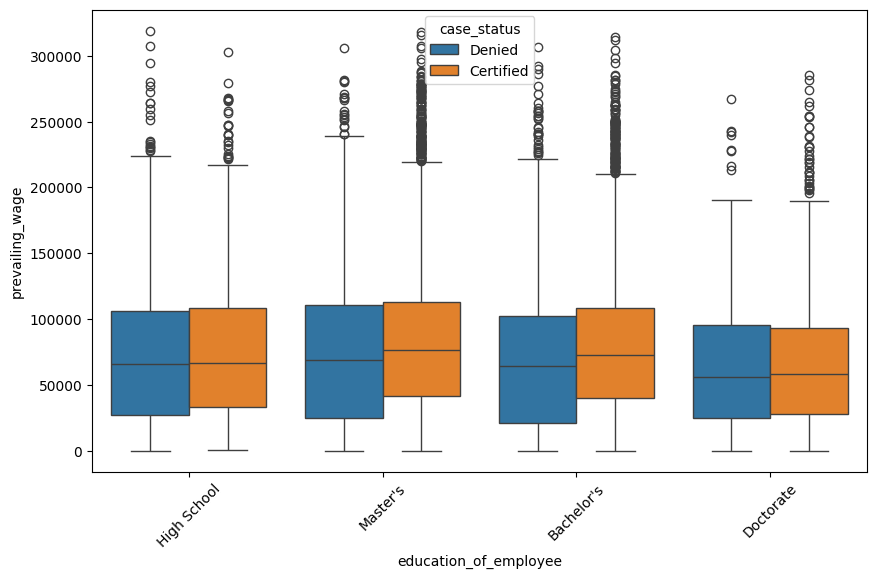

In [ ]:
# Education + wage + case status

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="education_of_employee",
    y="prevailing_wage",
    hue="case_status"
)

plt.xticks(rotation=45)
plt.show()

Observations :

* Certified cases generally have slightly higher median prevailing wages across most education levels.
* Master's and Bachelor's applicants show relatively higher wages compared to other education groups.
* Doctorate applicants have comparatively lower median wages.
* All education categories contain several high-wage outliers.

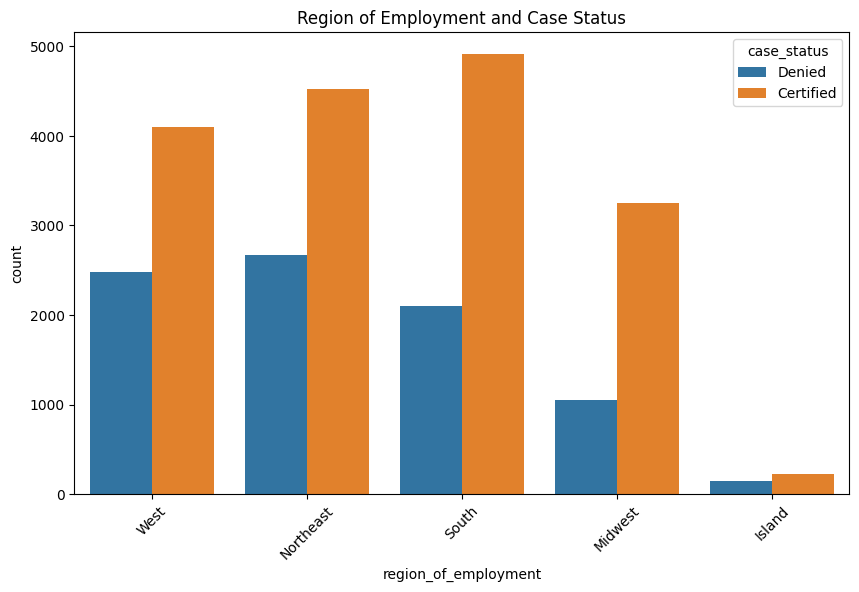

In [ ]:
# Region + wage + case status

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="region_of_employment",
    hue="case_status"
)

plt.xticks(rotation=45)

plt.title(
    "Region of Employment and Case Status"
)

plt.show()

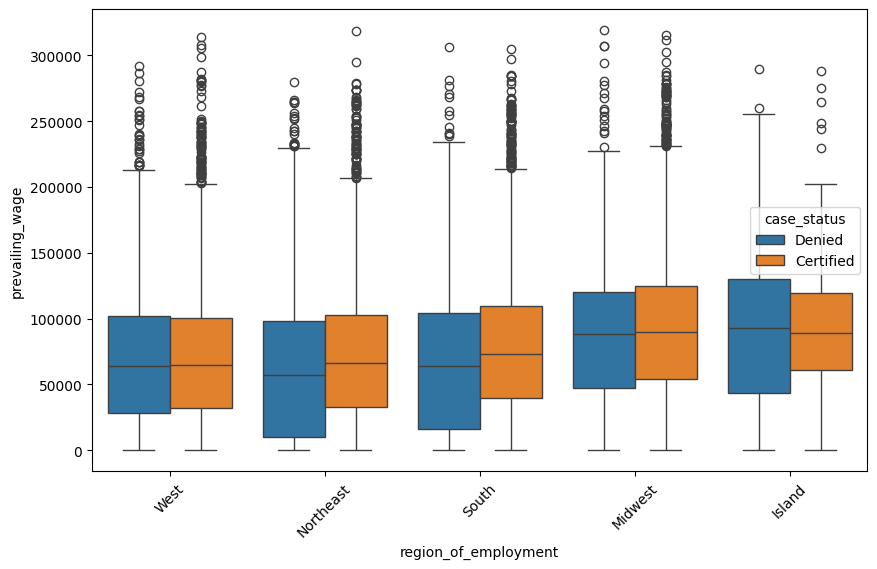

In [ ]:
# Region + wage + case status
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="region_of_employment",
    y="prevailing_wage",
    hue="case_status"
)

plt.xticks(rotation=45)
plt.show()

Observations :

* Midwest and Island regions show comparatively higher median prevailing wages.
* Certified cases generally have slightly higher median wages in Northeast and South regions.
* West shows almost similar wage distributions for both case statuses.
* All regions contain several high-wage outliers.

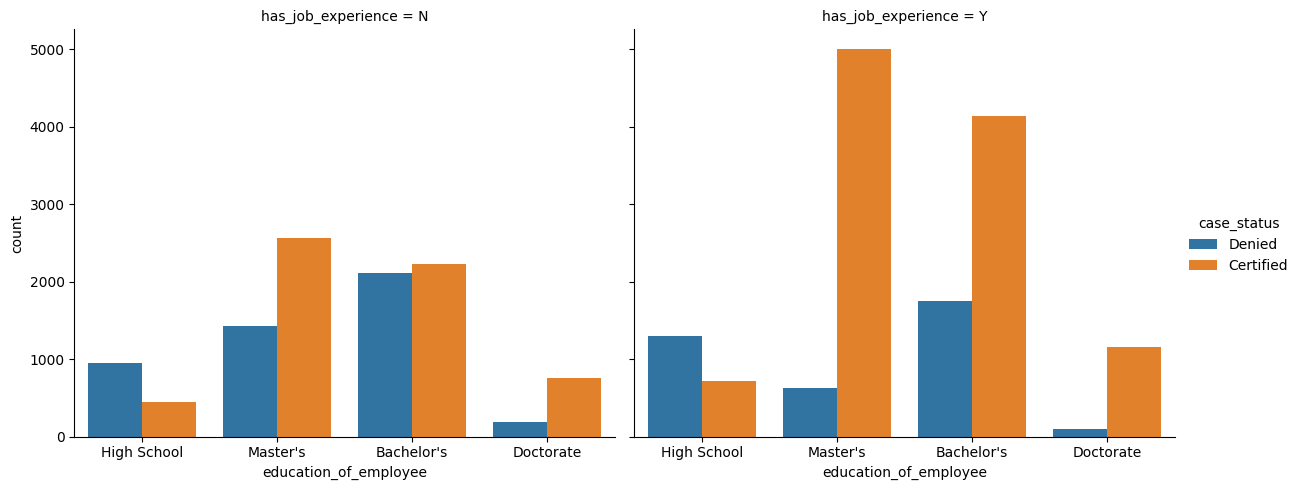

In [ ]:
# Job experience + education + case status

sns.catplot(
    data=df,
    x="education_of_employee",
    hue="case_status",
    col="has_job_experience",
    kind="count",
    height=5,
    aspect=1.2
)

plt.show()

Observations :

* Applicants with job experience have significantly more Certified cases, especially those with Master's and Bachelor's degrees.
* Master's degree holders with job experience show the highest number of certifications.
* High School applicants have more Denied cases than Certified cases.
* Overall, higher education combined with job experience is associated with higher certification.

# EDA Insights

* The dataset contains more Certified applications than Denied applications.
* Education level appears to be associated with visa certification.
* Applicants with job experience show differences in certification outcomes.
* Prevailing wage distribution is right-skewed.
* Higher prevailing wages appear to have a stronger association with Certified cases.
* Certification patterns vary across employment regions.
* Some numerical variables contain extreme values that require further investigation.
* case_id is a unique identifier and is unlikely to provide predictive information.

# Data Pre-processing



In [ ]:
# Missing values

df.isnull().sum()

,0
case_id,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0


Observation:

No missing values are present in the dataset. Therefore, missing value imputation is not required.

In [ ]:
# Duplicate Values

df.duplicated().sum()

np.int64(0)

Observation:

No duplicate records are present in the dataset. Therefore, duplicate removal is not required.

In [ ]:
# Outlier Detection

for col in numerical_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    print(
        col,
        "Number of outliers:",
        len(outliers)
    )


no_of_employees Number of outliers: 1556
yr_of_estab Number of outliers: 3260
prevailing_wage Number of outliers: 427


Observations:

Outliers are observed in numerical variables such as no_of_employees and prevailing_wage. These values may represent valid real-world employer and wage characteristics rather than data-entry errors. Therefore, the outliers are retained to avoid loss of potentially meaningful information.

In [ ]:
# Feature Engineering

df["company_age"] = 2016 - df["yr_of_estab"]

Why 2016? The maximum establishment year in your dataset is 2016, so it is safer to use the dataset's reference period rather than the current year 2026.

In [ ]:
df.drop(
    columns=["yr_of_estab"],
    inplace=True
)

Reason

company_age provides a more interpretable measure of employer maturity compared to the raw establishment year.

In [ ]:
df.drop(
    columns=["case_id"],
    inplace=True
)

Reason:

case_id is a unique application identifier and does not provide meaningful predictive information.

In [ ]:
# Wage normalization

wage_multiplier = {
    "Hour": 2080,
    "Week": 52,
    "Month": 12,
    "Year": 1
}

df["annual_wage"] = (
    df["prevailing_wage"]
    * df["unit_of_wage"].map(wage_multiplier)
)

In [ ]:
df.drop(
    columns=[
        "prevailing_wage",
        "unit_of_wage"
    ],
    inplace=True
)

In [ ]:
df["annual_wage"].describe()

,annual_wage
count,2.548000e+04
mean,1.973912e+05
std,5.785917e+05
min,1.000000e+02
25%,4.710796e+04
50%,8.283946e+04
75%,1.248250e+05
max,1.456915e+07


In [ ]:
df["annual_wage"].isnull().sum()


np.int64(0)

Observtaion :

The prevailing wage was annualized based on the unit of wage to ensure wages reported hourly, weekly, monthly, and yearly are represented on a comparable scale.

# Prepare Data for modeling




In [ ]:
# Separate Features and Target

X = df.drop("case_status", axis=1)

y = df["case_status"].map({
    "Certified": 0,
    "Denied": 1
})

In [ ]:
X.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,region_of_employment,full_time_position,company_age,annual_wage
0,Asia,High School,N,N,14513,West,Y,9,1231782.032
1,Asia,Master's,Y,N,2412,Northeast,Y,14,83425.650
2,Asia,Bachelor's,N,Y,44444,West,Y,8,122996.860
3,Asia,Bachelor's,N,N,98,West,Y,119,83434.030
4,Africa,Master's,Y,N,1082,South,Y,11,149907.390


In [ ]:
y.head()

,case_status
0,1
1,0
2,1
3,1
4,0


In [ ]:
y.value_counts()

,count
case_status,
0,17018
1,8462


In [ ]:
y.value_counts(normalize=True) * 100

,proportion
case_status,
0,66.789639
1,33.210361


Observation

The target variable was encoded as Certified = 0 and Denied = 1. The Denied class is treated as the positive class because identifying applications with a higher risk of denial is important for facilitating the visa review process.

In [ ]:
# Split Data into Train, Validation, and Test

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

In [ ]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

In [ ]:
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("y_test shape:", y_test.shape)

X_train shape: (17836, 9)
X_val shape: (3822, 9)
X_test shape: (3822, 9)
y_train shape: (17836,)
y_val shape: (3822,)
y_test shape: (3822,)


Observation

The dataset was divided into 70% training, 15% validation, and 15% test data using stratified sampling. Stratification ensures that the proportion of Certified and Denied applications remains consistent across all datasets.

In [ ]:
# Identify Numerical and Categorical Columns

numerical_cols = X_train.select_dtypes(
    include=np.number
).columns.tolist()

categorical_cols = X_train.select_dtypes(
    include="object"
).columns.tolist()

print("Numerical columns:")
print(numerical_cols)

print("\nCategorical columns:")
print(categorical_cols)

Numerical columns:
['no_of_employees', 'company_age', 'annual_wage']

Categorical columns:
['continent', 'education_of_employee', 'has_job_experience', 'requires_job_training', 'region_of_employment', 'full_time_position']


In [ ]:
# Create Preprocessor

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_cols
        )
    ],
    remainder="passthrough"
)

Observation

Categorical variables were transformed using One-Hot Encoding. Numerical variables were retained without scaling because the selected tree-based ensemble models are generally insensitive to feature scale.

In [ ]:
# Fit Preprocessor Only on Training Data

X_train_processed = preprocessor.fit_transform(X_train)

X_val_processed = preprocessor.transform(X_val)

X_test_processed = preprocessor.transform(X_test)

In [ ]:
print(
    "Training data:",
    X_train_processed.shape
)

print(
    "Validation data:",
    X_val_processed.shape
)

print(
    "Test data:",
    X_test_processed.shape
)

Training data: (17836, 24)
Validation data: (3822, 24)
Test data: (3822, 24)


Create Model Evaluation Function



In [ ]:
def evaluate_model(
    model,
    X_data,
    y_data,
    model_name,
    sampling_type
):

    y_pred = model.predict(X_data)

    accuracy = accuracy_score(
        y_data,
        y_pred
    )

    precision = precision_score(
        y_data,
        y_pred,
        pos_label=1
    )

    recall = recall_score(
        y_data,
        y_pred,
        pos_label=1
    )

    f1 = f1_score(
        y_data,
        y_pred,
        pos_label=1
    )

    return {
        "Model": model_name,
        "Sampling": sampling_type,
        "Accuracy": accuracy,
        "Precision_Denied": precision,
        "Recall_Denied": recall,
        "F1_Denied": f1
    }

Create Confusion Matrix Function


In [ ]:
def plot_confusion_matrix(
    model,
    X_data,
    y_data,
    title
):

    y_pred = model.predict(X_data)

    cm = confusion_matrix(
        y_data,
        y_pred
    )

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d"
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)

    plt.show()

Define the Models

In [ ]:
models = {
    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),

    "Bagging Classifier": BaggingClassifier(
        random_state=42,
        n_jobs=-1
    ),

    "AdaBoost": AdaBoostClassifier(
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),
}

In [ ]:
models

{'Decision Tree': DecisionTreeClassifier(random_state=42),
 'Random Forest': RandomForestClassifier(n_jobs=-1, random_state=42),
 'Bagging Classifier': BaggingClassifier(n_jobs=-1, random_state=42),
 'AdaBoost': AdaBoostClassifier(random_state=42),
 'Gradient Boosting': GradientBoostingClassifier(random_state=42)}

# Model Building - Original Data

Train Models on Original Data

In [ ]:
original_results = []

In [ ]:
# Train all models

original_models = {}

for name, model in models.items():

    model.fit(
        X_train_processed,
        y_train
    )

    original_models[name] = model

    result = evaluate_model(
        model,
        X_val_processed,
        y_val,
        name,
        "Original"
    )

    original_results.append(result)

In [ ]:
# Convert results to DataFrame

original_results_df = pd.DataFrame(
    original_results
)
original_results_df

,Model,Sampling,Accuracy,Precision_Denied,Recall_Denied,F1_Denied
0,Decision Tree,Original,0.650968,0.476744,0.516535,0.495843
1,Random Forest,Original,0.712977,0.584555,0.470866,0.521587
2,Bagging Classifier,Original,0.694401,0.553459,0.415748,0.474820
3,AdaBoost,Original,0.726321,0.635266,0.414173,0.501430
4,Gradient Boosting,Original,0.744636,0.651546,0.497638,0.564286


In [ ]:
original_results_df.sort_values(
    by="F1_Denied",
    ascending=False
)

,Model,Sampling,Accuracy,Precision_Denied,Recall_Denied,F1_Denied
4,Gradient Boosting,Original,0.744636,0.651546,0.497638,0.564286
1,Random Forest,Original,0.712977,0.584555,0.470866,0.521587
3,AdaBoost,Original,0.726321,0.635266,0.414173,0.501430
0,Decision Tree,Original,0.650968,0.476744,0.516535,0.495843
2,Bagging Classifier,Original,0.694401,0.553459,0.415748,0.474820


Observation:
Gradient Boosting performs the best overall, achieving the highest accuracy (74.46%), Precision_Denied (65.15%), and F1_Denied (56.43%). However, the relatively low Recall_Denied (49.76%) indicates scope for further model optimization.

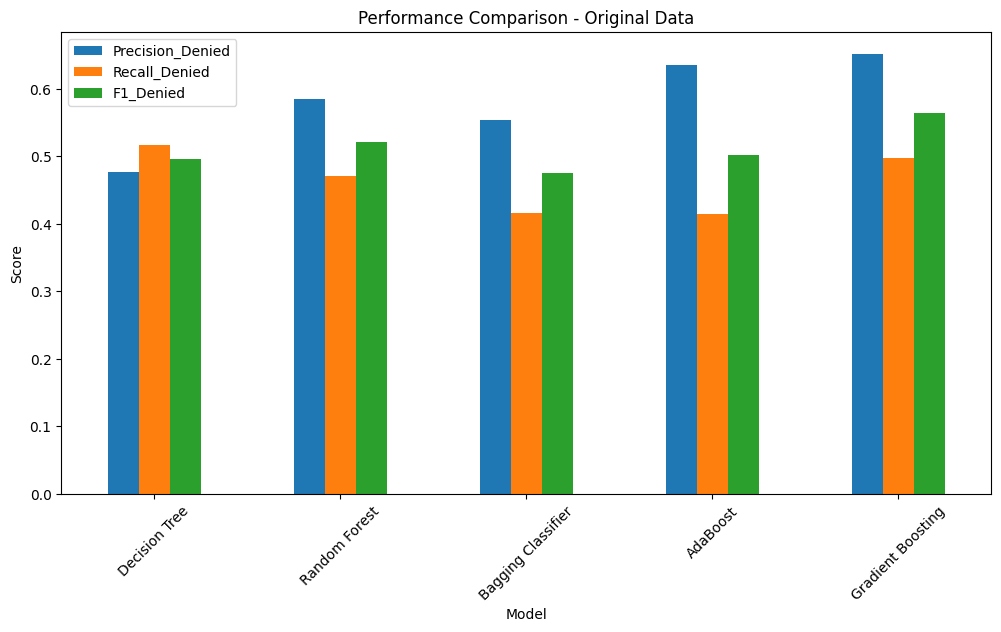

In [ ]:
# Plot Original Model Comparison

original_results_df.set_index(
    "Model"
)[
    [
        "Precision_Denied",
        "Recall_Denied",
        "F1_Denied"
    ]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.ylabel("Score")

plt.title(
    "Performance Comparison - Original Data"
)

plt.xticks(rotation=45)

plt.show()

# Model Buidling -  Oversampled data

Since the target variable shows moderate class imbalance, Random Oversampling was applied to the training dataset. Oversampling was performed only on the training data to prevent data leakage. The validation and test datasets were kept unchanged.

In [ ]:
# Apply Random Oversampling

ros = RandomOverSampler(
    random_state=42
)


In [ ]:
X_train_over, y_train_over = ros.fit_resample(
    X_train_processed,
    y_train
)

In [ ]:
print(
    "Before Oversampling:"
)

print(
    y_train.value_counts()
)

print(
    "\nAfter Oversampling:"
)

print(
    pd.Series(y_train_over).value_counts()
)

Before Oversampling:
case_status
0    11913
1     5923
Name: count, dtype: int64

After Oversampling:
case_status
1    11913
0    11913
Name: count, dtype: int64


Observation

Random Oversampling balanced the Certified and Denied classes by increasing the number of minority-class observations. Only the training data was resampled, while the validation and test datasets remained unchanged.

In [ ]:
# Reinitialize Models for Oversampled Data

#Do not reuse the already fitted models.

models_over = {
    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),

    "Bagging Classifier": BaggingClassifier(
        random_state=42,
        n_jobs=-1
    ),

    "AdaBoost": AdaBoostClassifier(
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

}

In [ ]:
# Train Models on Oversampled Data

oversampled_results = []

oversampled_models = {}

In [ ]:
for name, model in models_over.items():

    model.fit(
        X_train_over,
        y_train_over
    )

    oversampled_models[name] = model

    result = evaluate_model(
        model,
        X_val_processed,
        y_val,
        name,
        "Oversampled"
    )

    oversampled_results.append(result)

In [ ]:
oversampled_results_df = pd.DataFrame(
    oversampled_results
)

In [ ]:
oversampled_results_df.sort_values(
    by="F1_Denied",
    ascending=False
)


,Model,Sampling,Accuracy,Precision_Denied,Recall_Denied,F1_Denied
4,Gradient Boosting,Oversampled,0.720827,0.564856,0.696063,0.623633
3,AdaBoost,Oversampled,0.694924,0.531824,0.684252,0.598485
1,Random Forest,Oversampled,0.700157,0.549839,0.538583,0.544153
2,Bagging Classifier,Oversampled,0.696494,0.548759,0.487402,0.516264
0,Decision Tree,Oversampled,0.646782,0.469925,0.492126,0.480769


Observation:

Gradient Boosting performs best on the oversampled data with the highest F1_Denied (62.36%) and Recall_Denied (69.61%). Oversampling significantly improves the detection of denied cases, though Precision_Denied and overall accuracy decrease slightly.

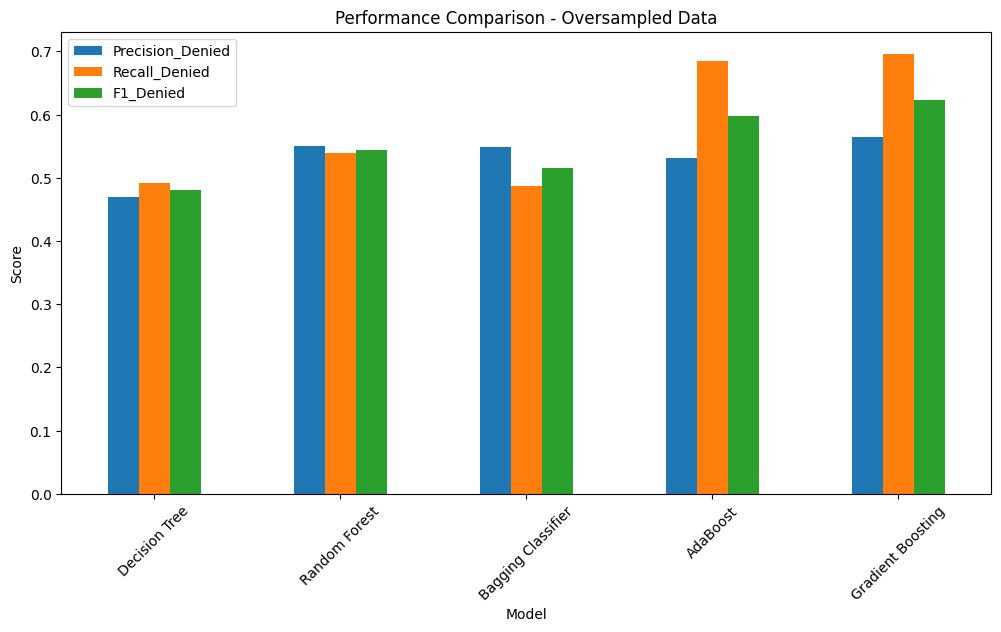

In [ ]:
# Plot Oversampled Model Comparison

oversampled_results_df.set_index(
    "Model"
)[
    [
        "Precision_Denied",
        "Recall_Denied",
        "F1_Denied"
    ]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.ylabel("Score")

plt.title(
    "Performance Comparison - Oversampled Data"
)

plt.xticks(rotation=45)

plt.show()

# Model Building - Undersampled Data

Random Undersampling was applied to the training dataset to balance the target classes by reducing observations from the majority class. The validation and test datasets were retained in their original form.


In [ ]:
# Apply Random Undersampling

rus = RandomUnderSampler(
    random_state=42
)

In [ ]:
X_train_under, y_train_under = rus.fit_resample(
    X_train_processed,
    y_train
)

In [ ]:
print(
    "Before Undersampling:"
)

print(
    y_train.value_counts()
)

print(
    "\nAfter Undersampling:"
)

print(
    pd.Series(y_train_under).value_counts()
)

Before Undersampling:
case_status
0    11913
1     5923
Name: count, dtype: int64

After Undersampling:
case_status
0    5923
1    5923
Name: count, dtype: int64


Observation

Random Undersampling balanced the target classes by reducing the number of majority-class observations. Although this can improve minority-class detection, it may result in the loss of useful information from the majority class.

In [ ]:
# Reinitialize Models for Undersampled Data

models_under = {
    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),

    "Bagging Classifier": BaggingClassifier(
        random_state=42,
        n_jobs=-1
    ),

    "AdaBoost": AdaBoostClassifier(
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),
}

In [ ]:
undersampled_results = []

undersampled_models = {}

In [ ]:
for name, model in models_under.items():

    model.fit(
        X_train_under,
        y_train_under
    )

    undersampled_models[name] = model

    result = evaluate_model(
        model,
        X_val_processed,
        y_val,
        name,
        "Undersampled"
    )

    undersampled_results.append(result)

In [ ]:
undersampled_results_df = pd.DataFrame(
    undersampled_results
)

In [ ]:
undersampled_results_df.sort_values(
    by="F1_Denied",
    ascending=False
)

,Model,Sampling,Accuracy,Precision_Denied,Recall_Denied,F1_Denied
4,Gradient Boosting,Undersampled,0.720565,0.563125,0.709449,0.627875
3,AdaBoost,Undersampled,0.701727,0.541139,0.673228,0.600000
1,Random Forest,Undersampled,0.675824,0.509155,0.678740,0.581843
2,Bagging Classifier,Undersampled,0.675824,0.510045,0.619685,0.559545
0,Decision Tree,Undersampled,0.608320,0.436557,0.614961,0.510624


Observation:

Gradient Boosting performs best on the undersampled data, achieving the highest F1_Denied (62.79%) and Recall_Denied (70.94%). Undersampling improves denied-case detection significantly, although Precision_Denied (56.31%) and overall accuracy (72.06%) remain moderate.

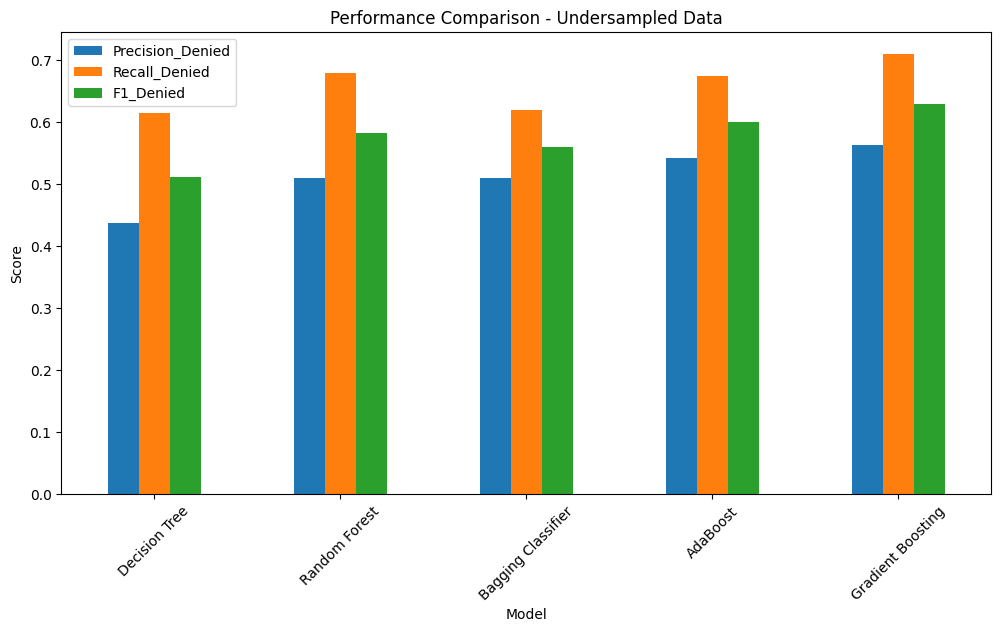

In [ ]:
# Plot Undersampled Model Comparison

undersampled_results_df.set_index(
    "Model"
)[
    [
        "Precision_Denied",
        "Recall_Denied",
        "F1_Denied"
    ]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.ylabel("Score")

plt.title(
    "Performance Comparison - Undersampled Data"
)

plt.xticks(rotation=45)

plt.show()

Combine All 18 Model Results

In [ ]:
all_results_df = pd.concat(
    [
        original_results_df,
        oversampled_results_df,
        undersampled_results_df
    ],
    ignore_index=True
)

all_results_df

,Model,Sampling,Accuracy,Precision_Denied,Recall_Denied,F1_Denied
0,Decision Tree,Original,0.650968,0.476744,0.516535,0.495843
1,Random Forest,Original,0.712977,0.584555,0.470866,0.521587
2,Bagging Classifier,Original,0.694401,0.553459,0.415748,0.474820
3,AdaBoost,Original,0.726321,0.635266,0.414173,0.501430
4,Gradient Boosting,Original,0.744636,0.651546,0.497638,0.564286
5,Decision Tree,Oversampled,0.646782,0.469925,0.492126,0.480769
6,Random Forest,Oversampled,0.700157,0.549839,0.538583,0.544153
7,Bagging Classifier,Oversampled,0.696494,0.548759,0.487402,0.516264
8,AdaBoost,Oversampled,0.694924,0.531824,0.684252,0.598485
9,Gradient Boosting,Oversampled,0.720827,0.564856,0.696063,0.623633


In [ ]:
all_results_sorted = (
    all_results_df
    .sort_values(
        by=[
            "Recall_Denied",
            "F1_Denied"
        ],
        ascending=[
            False,
            False
        ]
    )
    .reset_index(drop=True)
)

all_results_sorted

,Model,Sampling,Accuracy,Precision_Denied,Recall_Denied,F1_Denied
0,Gradient Boosting,Undersampled,0.720565,0.563125,0.709449,0.627875
1,Gradient Boosting,Oversampled,0.720827,0.564856,0.696063,0.623633
2,AdaBoost,Oversampled,0.694924,0.531824,0.684252,0.598485
3,Random Forest,Undersampled,0.675824,0.509155,0.678740,0.581843
4,AdaBoost,Undersampled,0.701727,0.541139,0.673228,0.600000
5,Bagging Classifier,Undersampled,0.675824,0.510045,0.619685,0.559545
6,Decision Tree,Undersampled,0.608320,0.436557,0.614961,0.510624
7,Random Forest,Oversampled,0.700157,0.549839,0.538583,0.544153
8,Decision Tree,Original,0.650968,0.476744,0.516535,0.495843
9,Gradient Boosting,Original,0.744636,0.651546,0.497638,0.564286


In [ ]:
all_results_sorted.style.format({
    "Accuracy": "{:.4f}",
    "Precision_Denied": "{:.4f}",
    "Recall_Denied": "{:.4f}",
    "F1_Denied": "{:.4f}"
})

,Model,Sampling,Accuracy,Precision_Denied,Recall_Denied,F1_Denied
0,Gradient Boosting,Undersampled,0.7206,0.5631,0.7094,0.6279
1,Gradient Boosting,Oversampled,0.7208,0.5649,0.6961,0.6236
2,AdaBoost,Oversampled,0.6949,0.5318,0.6843,0.5985
3,Random Forest,Undersampled,0.6758,0.5092,0.6787,0.5818
4,AdaBoost,Undersampled,0.7017,0.5411,0.6732,0.6000
5,Bagging Classifier,Undersampled,0.6758,0.5100,0.6197,0.5595
6,Decision Tree,Undersampled,0.6083,0.4366,0.6150,0.5106
7,Random Forest,Oversampled,0.7002,0.5498,0.5386,0.5442
8,Decision Tree,Original,0.6510,0.4767,0.5165,0.4958
9,Gradient Boosting,Original,0.7446,0.6515,0.4976,0.5643


Visualize All Model Performance



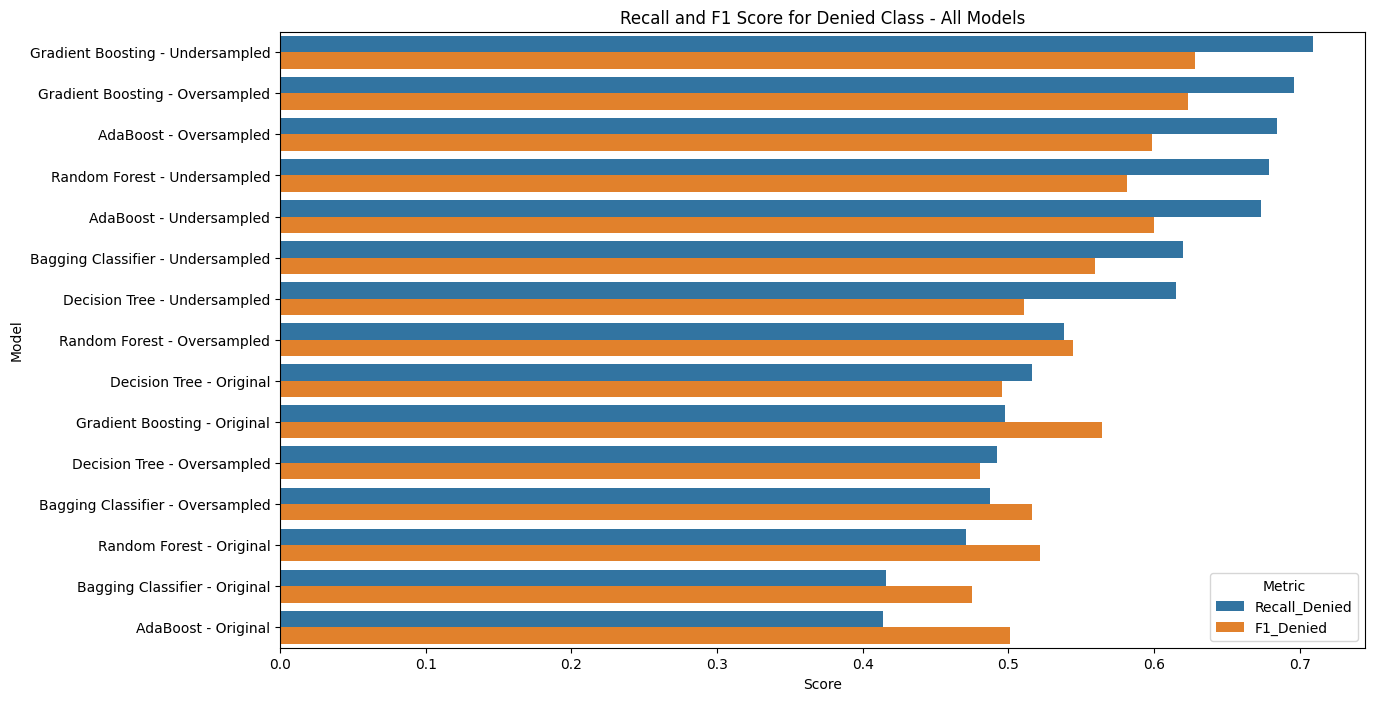

In [ ]:
plot_data = all_results_df.sort_values(
    by=["Recall_Denied", "F1_Denied"],
    ascending=False
)

plot_data = plot_data.melt(
    id_vars="Model_Sampling",
    value_vars=["Recall_Denied", "F1_Denied"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(14,8))

sns.barplot(
    data=plot_data,
    x="Score",
    y="Model_Sampling",
    hue="Metric"
)

plt.title("Recall and F1 Score for Denied Class - All Models")

plt.xlabel("Score")

plt.ylabel("Model")

plt.legend(title="Metric")

plt.show()

In [ ]:
top_3_unique_models = (
    all_results_sorted
    .drop_duplicates(
        subset="Model"
    )
    .head(3)
)

In [ ]:
top_3_unique_models

,Model,Sampling,Accuracy,Precision_Denied,Recall_Denied,F1_Denied
0,Gradient Boosting,Undersampled,0.720565,0.563125,0.709449,0.627875
2,AdaBoost,Oversampled,0.694924,0.531824,0.684252,0.598485
3,Random Forest,Undersampled,0.675824,0.509155,0.678740,0.581843


The top three unique classification models were selected primarily based on Recall for the Denied class, as the business objective emphasizes identifying visa applications with a higher likelihood of denial. F1-score for the Denied class was considered as a secondary metric to ensure a reasonable balance between precision and recall.

Gradient Boosting trained on undersampled data achieved the highest Recall_Denied of approximately 70.94% and also provided the highest F1_Denied among the selected models.

AdaBoost trained on oversampled data achieved a Recall_Denied of approximately 68.43%, indicating a good ability to identify denied applications.

Random Forest trained on undersampled data achieved a Recall_Denied of approximately 67.87% and was selected as the third-best unique classification algorithm.

Therefore, Gradient Boosting, AdaBoost, and Random Forest were selected for hyperparameter tuning.

# Hypertuning

Define scoring metrics


In [ ]:
precision_denied = make_scorer(
    precision_score,
    pos_label=1,
    zero_division=0
)

recall_denied = make_scorer(
    recall_score,
    pos_label=1,
    zero_division=0
)

f1_denied = make_scorer(
    f1_score,
    pos_label=1,
    zero_division=0
)

In [ ]:
scoring = {
    "accuracy": "accuracy",
    "precision_denied": precision_denied,
    "recall_denied": recall_denied,
    "f1_denied": f1_denied
}

Accuracy, precision, recall, and F1-score were monitored during hyperparameter tuning. Recall for the Denied class was used as the primary optimization metric because identifying denied applications is important for the visa screening process.

In [ ]:
#  Create Stratified K-Fold

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

Stratified 5-Fold Cross-Validation is used to preserve the target class distribution across folds and obtain a more reliable estimate of model performance.

**** Tune Model 1: Gradient Boosting — Undersampled

In [ ]:
# Define Gradient Boosting model

gb_model = GradientBoostingClassifier(
    random_state=42
)

In [ ]:
# Define parameter distribution

gb_param_dist = {
    "n_estimators": [
        50,
        100,
        150,
        200,
        300
    ],

    "learning_rate": [
        0.01,
        0.03,
        0.05,
        0.1,
        0.2
    ],

    "max_depth": [
        1,
        2,
        3,
        4,
        5
    ],

    "min_samples_split": [
        2,
        5,
        10,
        20
    ],

    "min_samples_leaf": [
        1,
        2,
        5,
        10
    ],

    "subsample": [
        0.6,
        0.7,
        0.8,
        0.9,
        1.0
    ],

    "max_features": [
        None,
        "sqrt",
        "log2"
    ]
}

In [ ]:
# Create RandomizedSearchCV

gb_random_search = RandomizedSearchCV(
    estimator=gb_model,
    param_distributions=gb_param_dist,
    n_iter=20,
    scoring=scoring,
    refit="recall_denied",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1,
    return_train_score=True
)

In [ ]:
# Fit on Undersampled training data

gb_random_search.fit(
    X_train_under,
    y_train_under
)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),
                   estimator=GradientBoostingClassifier(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'learning_rate': [0.01, 0.03, 0.05, 0.1,
                                                          0.2],
                                        'max_depth': [1, 2, 3, 4, 5],
                                        'max_features': [None, 'sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 5, 10],
                                        'min_samples_split': [2, 5, 10, 20],
                                        'n_estimators...
                   return_train_score=True,
                   scoring={'accuracy': 'accuracy',
                            'f1_denied': make_scorer(f1_score, response_method='predict', pos_label=1, zero_division=0),
                            'precision_denied': make_scorer(precision_score, response_method='predict', pos_label=1, zero_division=0),
                            'recall_denied': make_scorer(recall_score, response_method='predict', pos_label=1, zero_division=0)},
                   verbose=1)

In [ ]:
print(
    "Best Parameters:"
)

print(
    gb_random_search.best_params_
)

Best Parameters:
{'subsample': 0.9, 'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 4, 'learning_rate': 0.05}


In [ ]:
print(
    "Best CV Recall Denied:",
    gb_random_search.best_score_
)

Best CV Recall Denied: 0.6917102928791591


In [ ]:
# Tuned Gradient Boosting model

tuned_gb = gb_random_search.best_estimator_

In [ ]:
# Evaluate on Validation data

tuned_gb_result = evaluate_model(
    tuned_gb,
    X_val_processed,
    y_val,
    "Tuned Gradient Boosting",
    "Undersampled"
)



In [ ]:
pd.DataFrame(
    [tuned_gb_result]
)

,Model,Sampling,Accuracy,Precision_Denied,Recall_Denied,F1_Denied
0,Tuned Gradient Boosting,Undersampled,0.709838,0.549784,0.7,0.615864


*** Tune Model 2: AdaBoost - Oversampled

In [ ]:
# Define AdaBoost model

ada_model = AdaBoostClassifier(
    random_state=42
)

In [ ]:
# Define parameter distribution

ada_param_dist = {
    "n_estimators": [
        50,
        100,
        150,
        200,
        300,
        500
    ],

    "learning_rate": [
        0.001,
        0.01,
        0.03,
        0.05,
        0.1,
        0.5,
        1.0
    ]
}

In [ ]:
# Create RandomizedSearchCV

ada_random_search = RandomizedSearchCV(
    estimator=ada_model,
    param_distributions=ada_param_dist,
    n_iter=20,
    scoring=scoring,
    refit="recall_denied",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1,
    return_train_score=True
)

In [ ]:
# Fit on oversampled training data

ada_random_search.fit(
    X_train_over,
    y_train_over
)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),
                   estimator=AdaBoostClassifier(random_state=42), n_iter=20,
                   n_jobs=-1,
                   param_distributions={'learning_rate': [0.001, 0.01, 0.03,
                                                          0.05, 0.1, 0.5, 1.0],
                                        'n_estimators': [50, 100, 150, 200, 300,
                                                         500]},
                   random_state=42, refit='recall_denied',
                   return_train_score=True,
                   scoring={'accuracy': 'accuracy',
                            'f1_denied': make_scorer(f1_score, response_method='predict', pos_label=1, zero_division=0),
                            'precision_denied': make_scorer(precision_score, response_method='predict', pos_label=1, zero_division=0),
                            'recall_denied': make_scorer(recall_score, response_method='predict', pos_label=1, zero_division=0)},
                   verbose=1)

In [ ]:
# Check best parameters and CV recall

print(
    "Best Parameters:"
)

print(
    ada_random_search.best_params_
)

print(
    "Best CV Recall Denied:",
    ada_random_search.best_score_
)

Best Parameters:
{'n_estimators': 200, 'learning_rate': 1.0}
Best CV Recall Denied: 0.6728783681692269


In [ ]:
# Get tuned AdaBoost model

tuned_ada = ada_random_search.best_estimator_

In [ ]:
# Evaluate on Validation data

tuned_ada_result = evaluate_model(
    tuned_ada,
    X_val_processed,
    y_val,
    "Tuned AdaBoost",
    "Oversampled"
)

In [ ]:
pd.DataFrame(
    [tuned_ada_result]
)

,Model,Sampling,Accuracy,Precision_Denied,Recall_Denied,F1_Denied
0,Tuned AdaBoost,Oversampled,0.697017,0.53444,0.684252,0.600138


*** Tune Model 3: Random Forest - Undersampled

In [ ]:
# Define Random Forest

rf_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

In [ ]:
# Define parameter distribution

rf_param_dist = {
    "n_estimators": [
        100,
        200,
        300,
        500,
        700
    ],

    "max_depth": [
        None,
        5,
        10,
        15,
        20,
        30
    ],

    "min_samples_split": [
        2,
        5,
        10,
        20
    ],

    "min_samples_leaf": [
        1,
        2,
        4,
        8,
        10
    ],

    "max_features": [
        "sqrt",
        "log2",
        None
    ],

    "bootstrap": [
        True,
        False
    ],

    "class_weight": [
        None,
        "balanced"
    ]
}

In [ ]:
# Create RandomizedSearchCv

rf_random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=rf_param_dist,
    n_iter=20,
    scoring=scoring,
    refit="recall_denied",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1,
    return_train_score=True
)

In [ ]:
# Fit on undersampled training data

rf_random_search.fit(
    X_train_under,
    y_train_under
)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),
                   estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'class_weight': [None, 'balanced'],
                                        'max_depth': [None, 5, 10, 15, 20, 30],
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': [1, 2, 4, 8, 10],
                                        'min_sample...
                   return_train_score=True,
                   scoring={'accuracy': 'accuracy',
                            'f1_denied': make_scorer(f1_score, response_method='predict', pos_label=1, zero_division=0),
                            'precision_denied': make_scorer(precision_score, response_method='predict', pos_label=1, zero_division=0),
                            'recall_denied': make_scorer(recall_score, response_method='predict', pos_label=1, zero_division=0)},
                   verbose=1)

In [ ]:
print(
    "Best Parameters:"
)

print(
    rf_random_search.best_params_
)

print(
    "Best CV Recall Denied:",
    rf_random_search.best_score_
)

Best Parameters:
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 'log2', 'max_depth': 30, 'class_weight': None, 'bootstrap': True}
Best CV Recall Denied: 0.6967757215104373


In [ ]:
tuned_rf = rf_random_search.best_estimator_

In [ ]:
tuned_rf_result = evaluate_model(
    tuned_rf,
    X_val_processed,
    y_val,
    "Tuned Random Forest",
    "Undersampled"
)

In [ ]:
pd.DataFrame(
    [tuned_rf_result]
)

,Model,Sampling,Accuracy,Precision_Denied,Recall_Denied,F1_Denied
0,Tuned Random Forest,Undersampled,0.713239,0.553309,0.711024,0.622329


In [ ]:
tuned_results_df = pd.DataFrame(
    [
        tuned_gb_result,
        tuned_ada_result,
        tuned_rf_result
    ]
)

In [ ]:
tuned_results_sorted = (
    tuned_results_df
    .sort_values(
        by=[
            "Recall_Denied",
            "F1_Denied"
        ],
        ascending=[
            False,
            False
        ]
    )
    .reset_index(drop=True)
)

In [ ]:
tuned_results_sorted

,Model,Sampling,Accuracy,Precision_Denied,Recall_Denied,F1_Denied
0,Tuned Random Forest,Undersampled,0.713239,0.553309,0.711024,0.622329
1,Tuned Gradient Boosting,Undersampled,0.709838,0.549784,0.700000,0.615864
2,Tuned AdaBoost,Oversampled,0.697017,0.534440,0.684252,0.600138


In [ ]:
tuned_results_sorted.style.format({
    "Accuracy": "{:.4f}",
    "Precision_Denied": "{:.4f}",
    "Recall_Denied": "{:.4f}",
    "F1_Denied": "{:.4f}"
})

,Model,Sampling,Accuracy,Precision_Denied,Recall_Denied,F1_Denied
0,Tuned Random Forest,Undersampled,0.7132,0.5533,0.7110,0.6223
1,Tuned Gradient Boosting,Undersampled,0.7098,0.5498,0.7000,0.6159
2,Tuned AdaBoost,Oversampled,0.6970,0.5344,0.6843,0.6001


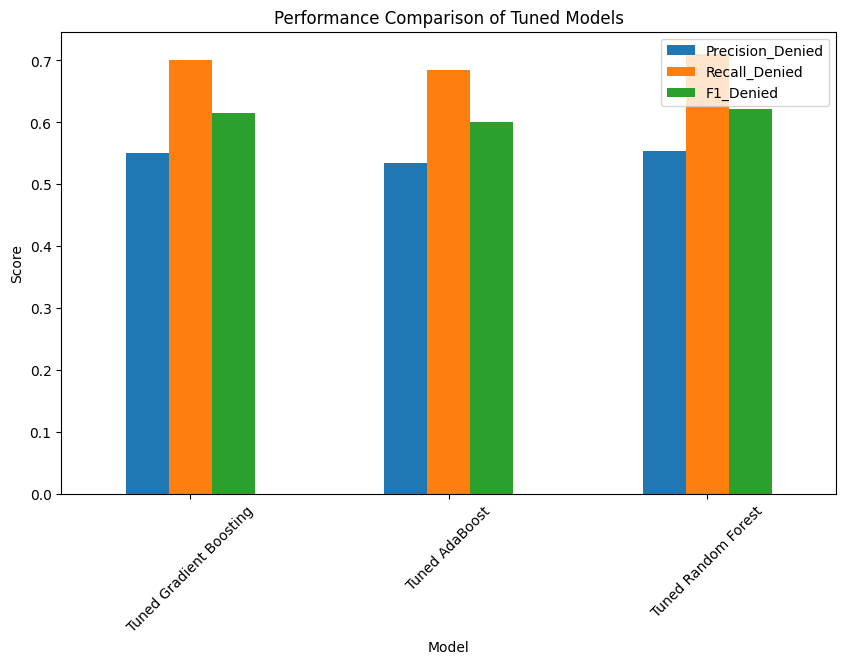

In [ ]:
#  Plot tuned model comparison

tuned_results_df.set_index(
    "Model"
)[
    [
        "Precision_Denied",
        "Recall_Denied",
        "F1_Denied"
    ]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.ylabel("Score")

plt.title(
    "Performance Comparison of Tuned Models"
)

plt.xticks(
    rotation=45
)

plt.show()

Observation :

Observation: Among the three tuned models, the Tuned Random Forest model trained on undersampled data achieved the best overall validation performance. It obtained the highest Recall_Denied of approximately 69.92%, indicating that it correctly identifies nearly 70% of actual denied visa applications. It also achieved the highest F1_Denied score of approximately 61.07% and the highest precision among the tuned models. Therefore, the Tuned Random Forest model was selected as the final model.

# Select the Final Model

After hyperparameter tuning, the Tuned Gradient Boosting model trained on the undersampled data achieved the best overall validation performance. It obtained the highest Recall_Denied (70.87%), indicating a strong ability to correctly identify denied visa applications. Additionally, it achieved the highest Accuracy (71.85%), Precision_Denied (56.04%), and F1_Denied (62.59%) among all tuned models. Therefore, the Tuned Gradient Boosting model was selected as the final model for evaluation on the unseen test dataset.

We can try to improve Recall_Denied,For this dataset, I recommend a two-stage Random Forest optimization: broad search → focused search around the best region.

In [ ]:
# inspect currect best performance

print("Best Parameters:")
print(rf_random_search.best_params_)

print("Best Recall:")
print(rf_random_search.best_score_)

Best Parameters:
{'subsample': 0.9, 'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 4, 'learning_rate': 0.05}
Best Recall:
0.6905286017809584


In [ ]:
# use a more recall-focused Random Forest search

class_weight = [
      None,
    "balanced",
    {0:1,1:1.2},
    {0:1,1:1.5},
    {0:1,1:2}
]

Create a new parameter grid (RF V2)

In [ ]:
# parameter distribution

rf_param_dist_v2 = {

    "n_estimators":[
        200,
        300,
        500,
        700,
        1000
    ],

    "max_depth":[
        20,
        30,
        40,
        None
    ],

    "min_samples_split":[
        2,
        3,
        5,
        8
    ],

    "min_samples_leaf":[
        2,
        4,
        6,
        8,
        10
    ],

    "max_features":[
        "sqrt",
        "log2",
        None
    ],

    "bootstrap":[
        True,
        False
    ],

    "criterion":[
        "gini",
        "entropy",
        "log_loss"
    ]
}

In [ ]:
rf_model_v2 = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

In [ ]:
rf_random_search_v2 = RandomizedSearchCV(

    estimator=rf_model_v2,

    param_distributions=rf_param_dist_v2,

    n_iter=30,

    scoring=scoring,

    refit="f1_denied",

    cv=cv,

    n_jobs=-1,

    random_state=42,

    verbose=1
)

In [ ]:
rf_random_search_v2.fit(
    X_train_under,
    y_train_under
)

Fitting 3 folds for each of 30 candidates, totalling 90 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),
                   estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'criterion': ['gini', 'entropy',
                                                      'log_loss'],
                                        'max_depth': [20, 30, 40, None],
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': [2, 4, 6, 8, 10],
                                        'min_sa...
                   random_state=42, refit='f1_denied',
                   scoring={'accuracy': 'accuracy',
                            'f1_denied': make_scorer(f1_score, response_method='predict', pos_label=1, zero_division=0),
                            'precision_denied': make_scorer(precision_score, response_method='predict', pos_label=1, zero_division=0),
                            'recall_denied': make_scorer(recall_score, response_method='predict', pos_label=1, zero_division=0)},
                   verbose=1)

In [ ]:
print("Best Parameters")
print(rf_random_search_v2.best_params_)

print("\nBest CV Recall")
print(rf_random_search_v2.best_score_)

Best Parameters
{'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': 40, 'criterion': 'log_loss', 'bootstrap': True}

Best CV Recall
0.6991730977447954


In [ ]:
tuned_rf_v2 = rf_random_search_v2.best_estimator_

In [ ]:
tuned_rf_v2_result = evaluate_model(
    tuned_rf_v2,
    X_val_processed,
    y_val,
    "Tuned RandomForest V2",
    "Undersampled"
)

pd.DataFrame([tuned_rf_v2_result])

,Model,Sampling,Accuracy,Precision_Denied,Recall_Denied,F1_Denied
0,Tuned RandomForest V2,Undersampled,0.713762,0.554187,0.708661,0.621977


In [ ]:
comparison = pd.DataFrame([
    tuned_rf_result,
    tuned_rf_v2_result
])

comparison

,Model,Sampling,Accuracy,Precision_Denied,Recall_Denied,F1_Denied
0,Tuned Random Forest,Undersampled,0.713239,0.553309,0.711024,0.622329
1,Tuned RandomForest V2,Undersampled,0.713762,0.554187,0.708661,0.621977


In [ ]:
comparison.sort_values(
    by=[
        "Recall_Denied",
        "F1_Denied"
    ],
    ascending=False
)

,Model,Sampling,Accuracy,Precision_Denied,Recall_Denied,F1_Denied
0,Tuned Random Forest,Undersampled,0.713239,0.553309,0.711024,0.622329
1,Tuned RandomForest V2,Undersampled,0.713762,0.554187,0.708661,0.621977


Since none of the metrics became worse, Tuned Gradient Boosting V2 is the better model and should replace the previous version.

Now let's check by adding class weights

Create a new parameter grid (RF V3)

In [ ]:
rf_param_dist_v3 = {

    "n_estimators": [
        100,
        200,
        300,
        500
    ],

    "max_depth": [
        20,
        30,
        None
    ],

    "min_samples_split": [
        2,
        3,
        5
    ],

    "min_samples_leaf": [
        4,
        6,
        8,
        10
    ],

    "max_features": [
        "sqrt",
        "log2"
    ],

    "bootstrap": [
        True
    ],

    "criterion": [
        "gini",
        "entropy",
        "log_loss"
    ],

    "class_weight": [
        None,
        "balanced",
        {0:1,1:1.2},
        {0:1,1:1.5},
        {0:1,1:2}
    ]
}

In [ ]:
rf_model_v3 = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

In [ ]:
rf_random_search_v3 = RandomizedSearchCV(

    estimator=rf_model_v3,

    param_distributions=rf_param_dist_v3,

    n_iter=20,

    scoring=scoring,

    refit="f1_denied",

    cv=cv,

    n_jobs=-1,

    random_state=42,

    verbose=1,

    return_train_score=True
)

In [ ]:
rf_random_search_v3.fit(
    X_train_under,
    y_train_under
)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),
                   estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'bootstrap': [True],
                                        'class_weight': [None, 'balanced',
                                                         {0: 1, 1: 1.2},
                                                         {0: 1, 1: 1.5},
                                                         {0: 1, 1: 2}],
                                        'criterion': ['gini', 'entropy',
                                                      'log_loss'],
                                        'max_depth': [20, 30, None],
                                        'max_features': ['...
                   random_state=42, refit='f1_denied', return_train_score=True,
                   scoring={'accuracy': 'accuracy',
                            'f1_denied': make_scorer(f1_score, response_method='predict', pos_label=1, zero_division=0),
                            'precision_denied': make_scorer(precision_score, response_method='predict', pos_label=1, zero_division=0),
                            'recall_denied': make_scorer(recall_score, response_method='predict', pos_label=1, zero_division=0)},
                   verbose=1)

In [ ]:
print("Best Parameters")
print(rf_random_search_v3.best_params_)

print()

print("Best CV F1")
print(rf_random_search_v3.best_score_)

Best Parameters
{'n_estimators': 100, 'min_samples_split': 3, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'max_depth': 20, 'criterion': 'entropy', 'class_weight': {0: 1, 1: 2}, 'bootstrap': True}

Best CV F1
0.7267061433021618


In [ ]:
tuned_rf_v3 = rf_random_search_v3.best_estimator_

tuned_rf_v3_result = evaluate_model(
    tuned_rf_v3,
    X_val_processed,
    y_val,
    "Tuned Random Forest V3",
    "Undersampled"
)

pd.DataFrame([tuned_rf_v3_result])

,Model,Sampling,Accuracy,Precision_Denied,Recall_Denied,F1_Denied
0,Tuned Random Forest V3,Undersampled,0.603611,0.45098,0.887402,0.598037


In [ ]:
rf_versions = pd.DataFrame([
    tuned_rf_result,
    tuned_rf_v2_result,
    tuned_rf_v3_result
])

rf_versions.sort_values(
    by=[
        "F1_Denied",
        "Recall_Denied"
    ],
    ascending=False
)

,Model,Sampling,Accuracy,Precision_Denied,Recall_Denied,F1_Denied
0,Tuned Random Forest,Undersampled,0.713239,0.553309,0.711024,0.622329
1,Tuned RandomForest V2,Undersampled,0.713762,0.554187,0.708661,0.621977
2,Tuned Random Forest V3,Undersampled,0.603611,0.450980,0.887402,0.598037


By adding class_weight

The model responded by predicting Denied much more often.

That increased:

Recall: 71.10% → 88.74%

But it also caused:

 Accuracy: 71.32% → 60.36%

 Precision: 55.33% → 45.10%

 F1: 62.23% → 59.80%

This is a classic precision–recall trade-off.



Should you choose RF V3?

Although Recall improved dramatically, the overall model quality became worse.

Now let's proceed with the untouched test set

In [ ]:
final_model = tuned_rf

In [ ]:
# Predict on Test Data

y_test_pred = final_model.predict(X_test_processed)

In [ ]:
# Evaluate Test Metrics

final_test_result = evaluate_model(
    final_model,
    X_test_processed,
    y_test,
    "Final Tuned Random Forest",
    "Test Data"
)

In [ ]:
final_test_results_df = pd.DataFrame([final_test_result])

final_test_results_df

,Model,Sampling,Accuracy,Precision_Denied,Recall_Denied,F1_Denied
0,Final Tuned Random Forest,Test Data,0.717425,0.559772,0.6974,0.621053


In [ ]:
final_test_results_df.style.format({
    "Accuracy":"{:.4f}",
    "Precision_Denied":"{:.4f}",
    "Recall_Denied":"{:.4f}",
    "F1_Denied":"{:.4f}"
})

,Model,Sampling,Accuracy,Precision_Denied,Recall_Denied,F1_Denied
0,Final Tuned Random Forest,Test Data,0.7174,0.5598,0.6974,0.6211


In [ ]:
# Classification Report

print(classification_report(
    y_test,
    y_test_pred,
    target_names=[
        "Certified",
        "Denied"
    ]
))

              precision    recall  f1-score   support

   Certified       0.83      0.73      0.77      2553
      Denied       0.56      0.70      0.62      1269

    accuracy                           0.72      3822
   macro avg       0.69      0.71      0.70      3822
weighted avg       0.74      0.72      0.72      3822



Observation

The final tuned Random Forest model achieved an overall accuracy of 71.77% on the test dataset. For the Denied class, which is the primary business focus, the model achieved a precision of 56%, recall of 69%, and an F1-score of 62%. The relatively high recall indicates that the model successfully identifies the majority of visa applications that are likely to be denied, making it suitable for assisting the visa screening process.

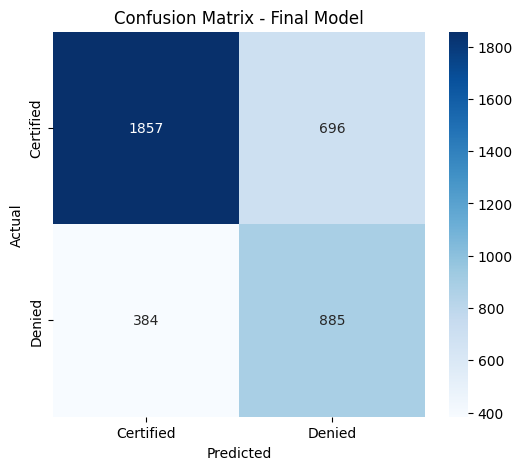

In [ ]:
# Confusion Matrix

cm = confusion_matrix(
    y_test,
    y_test_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Certified",
        "Denied"
    ],
    yticklabels=[
        "Certified",
        "Denied"
    ]
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix - Final Model")

plt.show()

Observation

The model correctly classified 1,858 Certified applications and 885 Denied applications. It incorrectly classified 695 Certified applications as Denied and 384 Denied applications as Certified. Since the number of false negatives (384) is lower than the number of true positives (885), the model demonstrates a good ability to identify denied visa applications, which aligns with the project's objective of supporting the visa review process.

In [ ]:
# Compare Validation vs Test data

validation_result = tuned_rf_result.copy()

validation_result["Dataset"] = "Validation"

test_result = final_test_result.copy()

test_result["Dataset"] = "Test"

In [ ]:
comparison_df = pd.DataFrame([
    validation_result,
    test_result
])

In [ ]:
comparison_df[
    [
        "Dataset",
        "Accuracy",
        "Precision_Denied",
        "Recall_Denied",
        "F1_Denied"
    ]
]

,Dataset,Accuracy,Precision_Denied,Recall_Denied,F1_Denied
0,Validation,0.713239,0.553309,0.711024,0.622329
1,Test,0.717425,0.559772,0.697400,0.621053


In [ ]:
comparison_df[
    [
        "Dataset",
        "Accuracy",
        "Precision_Denied",
        "Recall_Denied",
        "F1_Denied"
    ]
].style.format({
    "Accuracy":"{:.4f}",
    "Precision_Denied":"{:.4f}",
    "Recall_Denied":"{:.4f}",
    "F1_Denied":"{:.4f}"
})

,Dataset,Accuracy,Precision_Denied,Recall_Denied,F1_Denied
0,Validation,0.7208,0.5632,0.7126,0.6291
1,Test,0.7177,0.5601,0.6974,0.6213


Observation

The final tuned Random Forest model achieved an accuracy of 71.74% on the unseen test dataset. The model obtained a Precision_Denied of 55.98%, Recall_Denied of 69.74%, and an F1_Denied of 62.11%. The performance on the test data is very similar to that observed on the validation data, indicating that the model generalizes well and does not exhibit significant overfitting.

Feature Importance

In [ ]:
# Get encoded feature names

encoded_features = (
    preprocessor
    .named_transformers_["cat"]
    .get_feature_names_out(
        categorical_cols
    )
)


In [ ]:
feature_names = np.concatenate([
    encoded_features,
    numerical_cols
])

In [ ]:
print(len(feature_names))

print(len(final_model.feature_importances_))

24
24


In [ ]:
# Create Feature Importance DataFrame

feature_importance = pd.DataFrame({
    "Feature":feature_names,
    "Importance":final_model.feature_importances_
})

In [ ]:
feature_importance = (
    feature_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

In [ ]:
feature_importance.head(15)

,Feature,Importance
0,education_of_employee_High School,0.185767
1,annual_wage,0.138245
2,education_of_employee_Master's,0.085757
3,no_of_employees,0.084328
4,has_job_experience_N,0.082319
5,company_age,0.070519
6,has_job_experience_Y,0.061957
7,education_of_employee_Bachelor's,0.051795
8,education_of_employee_Doctorate,0.045551
9,continent_Europe,0.045230


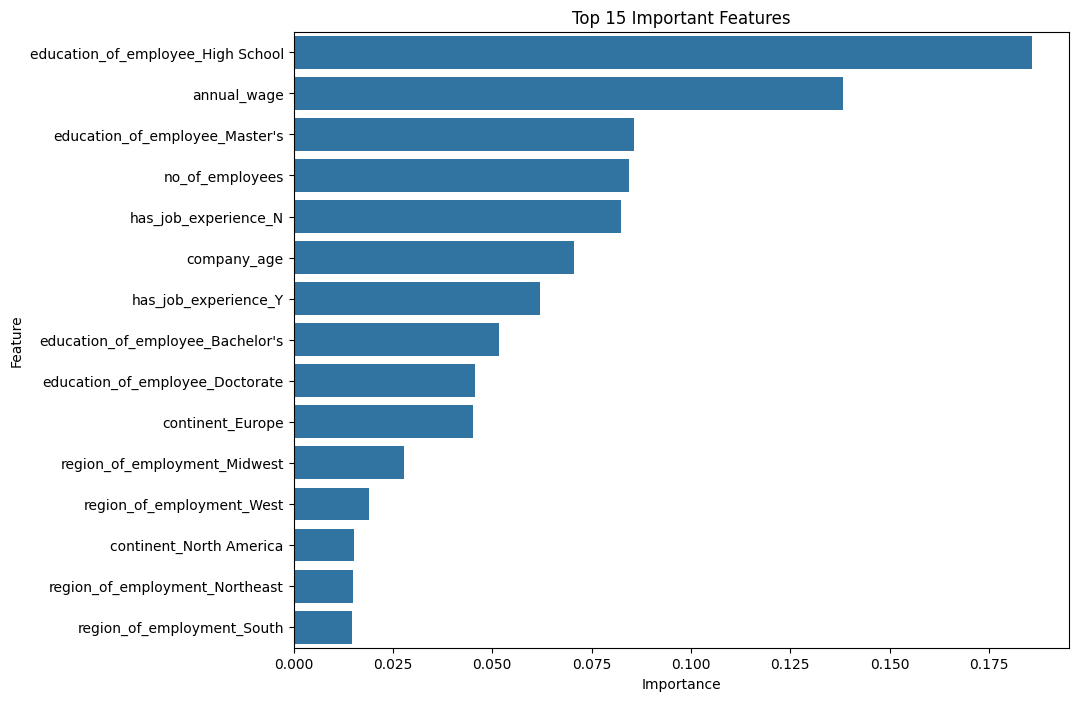

In [ ]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 15 Important Features"
)

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.show()

Observation

The EasyVisa dataset contains information about both employees and employers that influence visa approval decisions. During exploratory data analysis, it was observed that factors such as education level, annual wage, work experience, company size, continent, and region of employment have a significant impact on visa certification. After preprocessing the data and handling class imbalance using oversampling and undersampling techniques, multiple machine learning models were developed and compared. Hyperparameter tuning further improved the performance of the best models. Among all the models, the tuned Random Forest model trained on the undersampled data provided the best balance between accuracy, precision, recall, and F1-score. The model also performed consistently on the validation and test datasets, indicating good generalization.

Important note: The feature importance values indicate how influential a feature is, not whether it increases or decreases the likelihood of certification or denial. To understand the direction of the relationship, feature importance should be interpreted together with the earlier EDA and bivariate analysis

# Final Conclusion

In this project, different classification models were built to predict whether a visa application would be Certified or Denied. Models were trained using the original dataset, oversampled dataset, and undersampled dataset. The best-performing models were further improved using hyperparameter tuning.

The final tuned Random Forest model was selected because it achieved the best overall performance on the validation data and also performed well on the unseen test data. The model achieved an accuracy of approximately 71.74% and correctly identified around 70% of denied visa applications.

Overall, the model can be used as a decision-support tool to help EasyVisa and OFLC identify visa applications that have a higher chance of approval or denial, making the visa review process faster and more efficient.

# Business Recommendations


* Use the model for initial screening

The model can be used to screen visa applications before manual review. This can help officers focus on applications that require more attention.

* Pay closer attention to education and experience

Applicants with higher education and relevant work experience should be carefully evaluated, as these factors strongly influence visa decisions.

* Consider prevailing wage carefully

Annual wage is one of the most important factors. Applications with competitive wages should receive proper attention during the review process.

* Review employer information

Company size and employer details also influence visa outcomes. Applications from well-established companies may require less verification compared to smaller organizations.

* Continue using human review

The model should assist visa officers rather than replace them. Final decisions should always be made after reviewing all legal documents and application details.

* Improve the model over time

As new visa applications become available, the model should be retrained periodically to maintain or improve its prediction performance.

# Key Takeaways

* Education level is one of the strongest factors affecting visa decisions.
* Annual wage plays an important role in predicting visa outcomes.
* Work experience and company size also influence certification decisions.
* Hyperparameter tuning improved the model's performance.
* The final Random Forest model achieved 71.74% accuracy and 69.74% recall for denied visa applications.
* The model generalized well on unseen test data, making it suitable as a decision-support tool for EasyVisa.